In [1]:
%load_ext autoreload
%autoreload 2

import sys
# sys.path.append("/home/sabramov/packages/vinson")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
from matplotlib import rcParams

from torch.utils.data import DataLoader
#from torchdata.stateful_dataloader import StatefulDataLoader

from torchinfo import summary
from tqdm import tqdm
from genome_tools.data.anndata import read_zarr_backed

rcParams["font.sans-serif"] = ["IBM Plex Sans"]

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [226]:
import matplotlib
matplotlib.rcParams['figure.dpi'] = 300

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import anndata as ad

human_data = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')
human_data

AnnData object with n_obs × n_vars = 4159 × 5331170
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_type', '

In [5]:
vinson_training_data = human_data[
    human_data.obs.eval('pathological_state == "Normal" & SPOT3_score >= 0.2'),
    human_data.var.eval('autosomal_dhs'),
]
vinson_training_data

View of AnnData object with n_obs × n_vars = 2073 × 5093748
    obs: 'ln_number', 'ds_number', 'tc_number', 'core_annotation', 'extended_annotation', 'core_ontology_term', 'sample_type', 'system', 'subsystem', 'organ', 'organ_region', 'side_position', 'pathological_state', 'germ_layer', 'read_type', 'donor_age', 'donor_age_units', 'donor_ethnicity', 'donor_health_condition', 'donor_id', 'donor_sex', 'growth_stage', 'indiv_id', 'sample_source', 'dnasei_units', 'harvest_time', 'harvest_time_units', 'library_date', 'library_method', 'sample_extra', 'tc_extra', 'tissue_preparation', 'tissue_purification', 'core_treatment_name', 'treatment1_conc_units', 'treatment1_concentration', 'treatment1_duration', 'treatment1_duration_units', 'treatment1_name', 'treatment1_type', 'treatment2_conc_units', 'treatment2_concentration', 'treatment2_duration', 'treatment2_duration_units', 'treatment2_name', 'treatment2_type', 'treatment3_concentration', 'treatment3_duration', 'treatment3_name', 'treatment3_

In [6]:
sample_genotypes = pd.read_table("/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/meta+sample_ids.tsv").set_index('sample_id')
vinson_training_data.obsm['indiv_id'] = pd.DataFrame([], index=vinson_training_data.obs_names)
vinson_training_data.obsm['indiv_id']['indiv_id'] = sample_genotypes['indiv_id']
vinson_training_data.obsm['indiv_id']['indiv_id'] = vinson_training_data.obsm['indiv_id']['indiv_id'].fillna('None')
# vinson_training_data.obsm['indiv_id'] = vinson_training_data.obsm['indiv_id']['indiv_id'].values

/tmp/ipykernel_221910/1822460997.py:2: ImplicitModificationWarning: Setting element `.obsm['indiv_id']` of view, initializing view as actual.
  vinson_training_data.obsm['indiv_id'] = pd.DataFrame([], index=vinson_training_data.obs_names)


In [7]:
vinson_training_data.obsm['indiv_id']['indiv_id'][vinson_training_data.obsm['indiv_id']['indiv_id'] == "None"] = pd.NA

/tmp/ipykernel_221910/1633709699.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  vinson_training_data.obsm['indiv_id']['indiv_id'][vinson_training_data.obsm['indiv_id']['indiv_id'] == "None"] = pd.NA


In [8]:
vinson_training_data.obsm['indiv_id']['indiv_id'].isna().sum()

np.int64(300)

# Testing dataloader, model & loss function

In [9]:
from vinson.datasets.sequence import SequenceEmbedDataset
from vinson.models.sequence import BassetTrunkEmbed, CellEmbedding, EmbedModel
from vinson.loss import PoissonNLL

# Create trunk model
embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

#Create model
model = EmbedModel(trunk_model, embed_model, regression=True)

In [10]:
summary(model)

/home/sabramov/miniconda3/envs/pytorch/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Layer (type:depth-idx)                   Param #
EmbedModel                               --
├─BassetTrunkEmbed: 1-1                  --
│    └─Sequential: 2-1                   --
│    │    └─Conv1d: 3-1                  23,100
│    │    └─BatchNorm1d: 3-2             600
│    │    └─ReLU: 3-3                    --
│    │    └─MaxPool1d: 3-4               --
│    └─ReLU: 2-2                         --
│    └─Sequential: 2-3                   --
│    │    └─Conv1d: 3-5                  660,200
│    │    └─BatchNorm1d: 3-6             400
│    │    └─ReLU: 3-7                    --
│    │    └─MaxPool1d: 3-8               --
│    └─ReLU: 2-4                         --
│    └─Sequential: 2-5                   --
│    │    └─Conv1d: 3-9                  280,200
│    │    └─BatchNorm1d: 3-10            400
│    │    └─ReLU: 3-11                   --
│    │    └─MaxPool1d: 3-12              --
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       51,400
│    └

### Simulate the loss function

In [11]:
PoissonNLL(log_input=True, reduction="none")

PoissonNLL()

/tmp/ipykernel_221910/1862177680.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  d = np.exp(d)


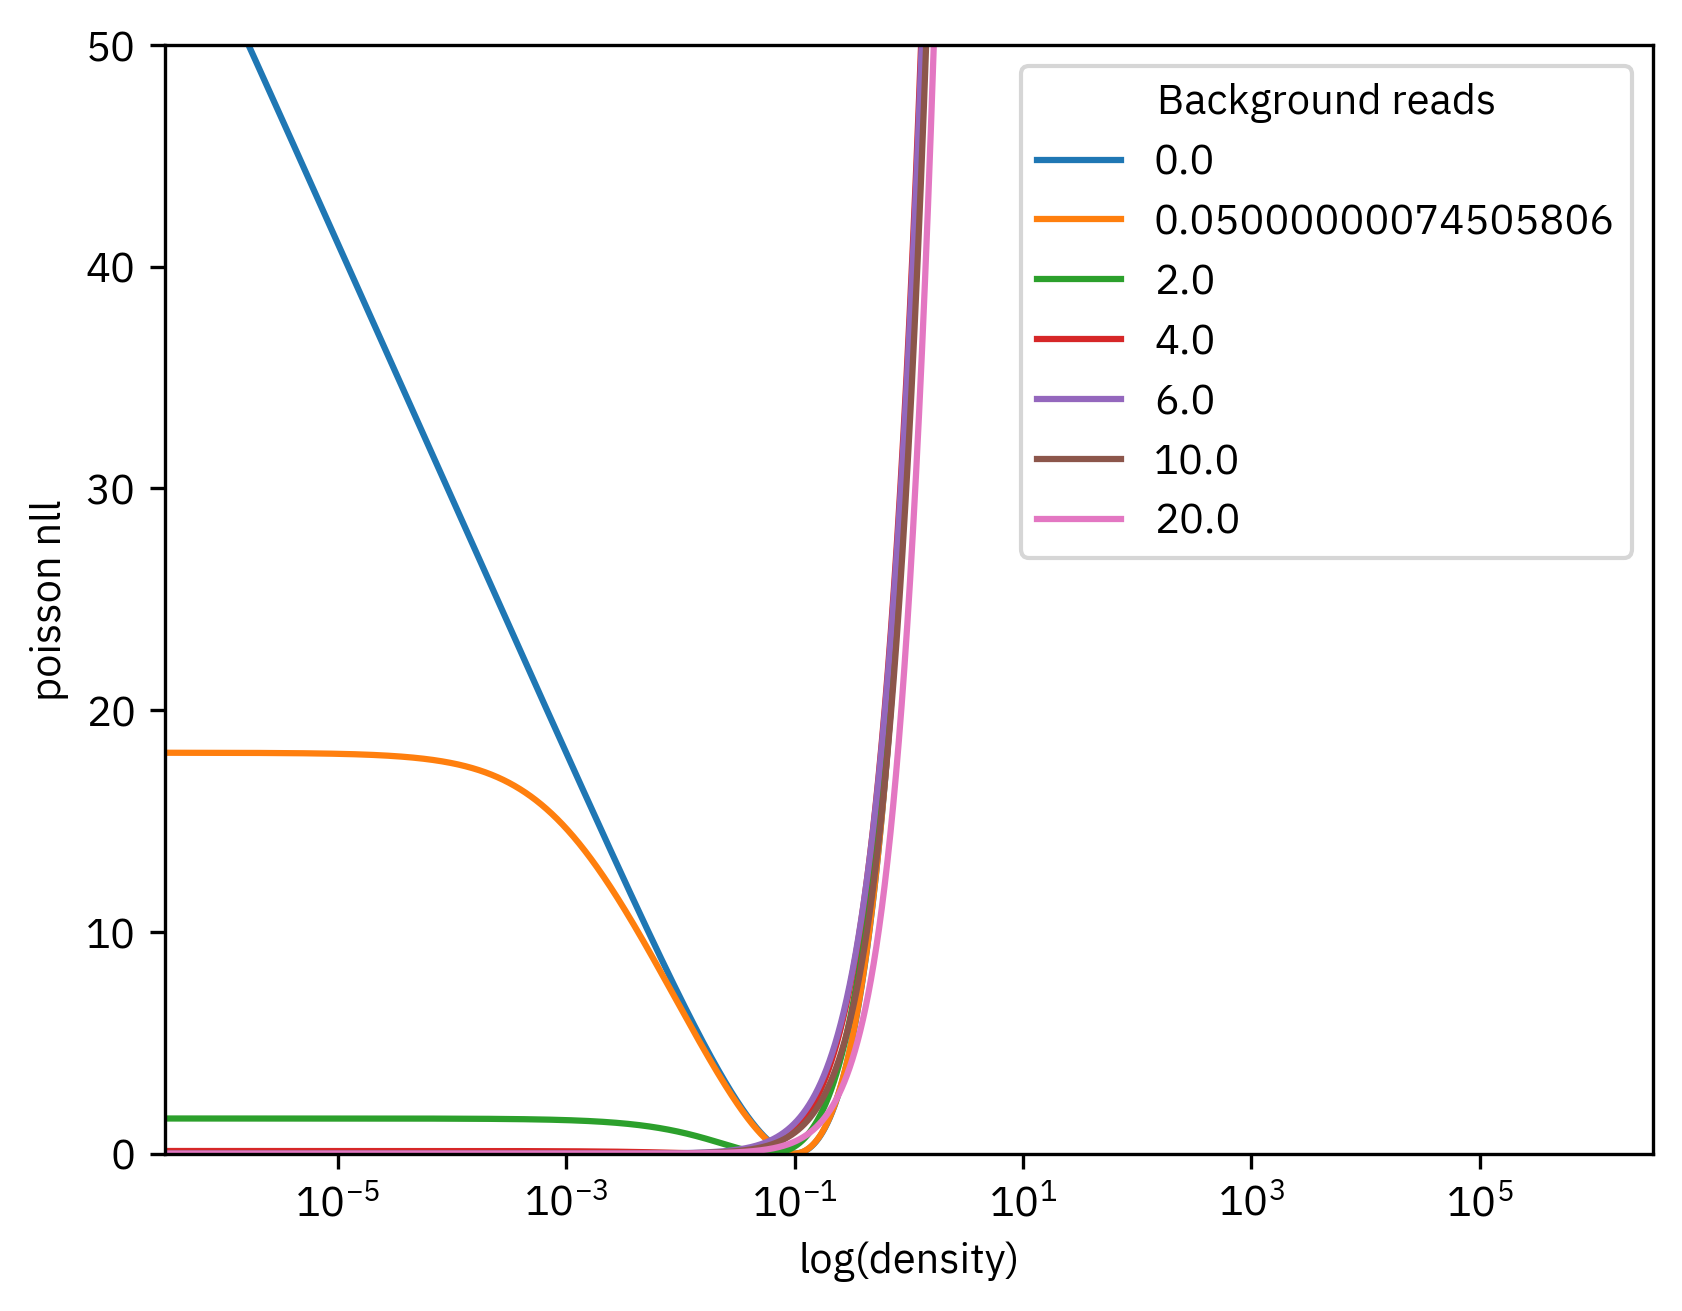

In [227]:
density = torch.tensor(0.1)
read_depth = torch.tensor(50e6)
bg_reads = torch.tensor([0, .05, 2, 4, 6, 10, 20])

d = torch.linspace(-15, 15, 10_000)
log_input = True

d = np.exp(d)
log_input = False

for bg in bg_reads:
    million = torch.tensor(1e6)

    if log_input:
        input = torch.logaddexp(
            d - million.log() + torch.log(read_depth), torch.log(bg)
        )
    else:
        input = d / million * read_depth + bg

    target_counts = torch.clip(density / million * read_depth, bg, None)

    loss = PoissonNLL(log_input=log_input, reduction="none")(input, target_counts)

    plt.plot(d, loss, label=f"{bg}")

plt.ylim(0, 50)
if not log_input:
    plt.xlim(np.exp(-15), np.exp(15))
    plt.xscale('log')
    
plt.xlabel("log(density)")
plt.ylabel("poisson nll")


plt.legend(title="Background reads")

### Load in dataset and dataloader

In [13]:
from vinson.datamodules.sequence import SeqEmbedDataModule
from vinson.utils.run import datamodule_from_config
import yaml

In [14]:
# anndata_file = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/OCT23//OCT23_3_epochs.h5ad'
# run_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_10_24_objective_leavitt/'
# config_path = run_path + 'run_config.yaml'
# checkpoint_path = run_path + 'checkpoints/epoch=4-step=4475871-val_loss=43.62.ckpt'

In [15]:
# anndata_file = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/OCT23//OCT23_3_epochs.h5ad'
# run_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_10_30_vigorous_heyrovsky/'
# config_path = run_path + 'run_config.yaml'
# checkpoint_path = run_path + 'checkpoints/epoch=3-step=3113653-val_loss=31.82.ckpt'

In [401]:
anndata_file = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/NOV03/NOV03_3_epochs_with_weights_fc_squared_50.h5ad'
run_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_11_04_trusting_goldwasser/'
config_path = run_path + 'run_config.yaml'
checkpoint_path = run_path + 'checkpoints/last.ckpt'

In [533]:
config_path

'/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_11_04_trusting_goldwasser/run_config.yaml'

In [105]:
with open(config_path) as f:
    vinson_config = yaml.safe_load(f)

vinson_config

{'command': 'python /home/sabramov/packages/vinson/train/dhs/train_dhs.py --run_name 2025_11_04_trusting_goldwasser --nodes 1 --accelerator gpu --strategy ddp --devices 8 --num_workers 12 --outdir /net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model --seed 42 --genotype_file /net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/all_variants_stats.bed.gz /net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/training_data/NOV03/NOV03_3_epochs_with_weights_fc_squared_50.h5ad /net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa --config /home/sabramov/packages/vinson/train/train_dhs_new_cluster_config_one_cycle_LR.yaml',
 'data_params': {'clip_density': 20, 'min_bg': 0.1, 'negatives_weight': 1},
 'hparams': {'batch_size': 32,
  'lr': 1e-05,
  'lr_scheduler': 'OneCycleLR',
  'lr_scheduler_kwargs': {'div_factor': 25,
   'final_div_factor': 10000,
   'max_lr': 0.001}},
 'logging_params': {'logger_type': 'csv', 'val_che

In [398]:
data_module.adata.uns['epoch_names']

array(['epoch_1', 'epoch_2', 'epoch_3'], dtype=object)

In [400]:
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/output/all_variants_stats.bed.gz"


data_module = datamodule_from_config(
    vinson_config,
    anndata_file=anndata_file,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    batch_size=256,
    num_workers=1,
    pin_memory=True,
)

data_module.setup('validate')

dataset = data_module.validation_dataset()
data_loader = DataLoader(dataset, shuffle=True, **data_module.dataloader_kwargs)

# train_dataset = data_module.train_dataset()
# train_data_loader = DataLoader(train_dataset, shuffle=True, **data_module.dataloader_kwargs)


## Load model checkpoint

In [107]:
def load_legacy_vinson(checkpoint_path):
    from vinson.models.sequence import BassetTrunkEmbed, EmbedModel
    class CellEmbedding(torch.nn.Module):

        def __init__(self, n_inputs, n_nodes=1024, n_outputs=128, n_layers=0):
            super(CellEmbedding, self).__init__()
    
            self.n_inputs = n_inputs
            self.n_nodes = n_nodes
            self.n_outputs = n_outputs
            self.n_layers = n_layers
    
            self.ifc = torch.nn.Linear(n_inputs, n_nodes)
            self.irelu = torch.nn.ReLU()
    
            self.fcs = torch.nn.ModuleList(
                [torch.nn.Linear(n_nodes, n_nodes) for i in range(self.n_layers)]
            )
            self.relus = torch.nn.ModuleList(
                [torch.nn.ReLU() for i in range(self.n_layers)]
            )
    
            self.ffc = torch.nn.Linear(n_nodes, n_outputs)
    
        def forward(self, embed):
            x = self.irelu(self.ifc(embed))
            for i in range(self.n_layers):
                x = self.relus[i](self.fcs[i](x))
            x = self.ffc(x)
            return x
        
    embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
    trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

    model_predict = EmbedModel(
        trunk_model,
        embed_model,
        regression=True,
        log_output=False,
    ).to(device)
    pretrained_state_dict = torch.load(
        checkpoint_path,
        map_location=torch.device("cpu"),
    )["state_dict"]

    model_predict.load_state_dict(pretrained_state_dict)
    return model_predict

In [402]:
# # Create trunk model
# embed_model = CellEmbedding(n_inputs=637, n_layers=0, n_outputs=256)
# trunk_model = BassetTrunkEmbed(embed_model.n_outputs)

# model_predict = EmbedModel.load_from_checkpoint(checkpoint_path, trunk=trunk_model, embed=embed_model)
# # model_predict = EmbedModel.load_from_checkpoint("/home/jvierstra/proj/vinson/models/data_OCT8_with_warmup_and_decay_v2/checkpoints/epoch=0-step=1401760-val_loss=25.82.ckpt", trunk=trunk_model, embed=embed_model)
# # model_predict = EmbedModel.load_from_checkpoint("/home/jvierstra/proj/vinson/models/data_AUG3_with_warmup_and_decay_v2/checkpoints/epoch=3-step=1851994-val_loss=16.16.ckpt", trunk=trunk_model, embed=embed_model)

# model_predict = model_predict.eval().to('cpu')

from vinson.utils.run import model_from_config

# model_predict = load_legacy_vinson(checkpoint_path=checkpoint_path).eval().to('cpu')
model_predict = model_from_config(config=vinson_config, checkpoint_path=checkpoint_path).eval().to('cpu')

/home/sabramov/miniconda3/envs/pytorch/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


### legnet model

In [568]:
# sys.path.append('/home/sabramov/packages/dnase_legnet/')

In [570]:
from dnase_legnet.legnet_embed_cnn import LegNetEmbedinCNN
legnet_checkpoint = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/checkpoints/LegNetEmbedinCNN/EmbedLegNet_last_epoch=199.ckpt'
legnet_model = LegNetEmbedinCNN.load_from_checkpoint(legnet_checkpoint, map_location='cpu').eval()

### Predict variants (random batch)

In [403]:
dataiter = iter(data_loader)

In [404]:
import logging
logging.getLogger().setLevel(logging.INFO)

batch = next(dataiter)


X_seq, X_embed, indicator, density, bg, read_depth, sample_id, chrom, mid, weight = (
    batch["ohe_seq"],
    batch["embed"],
    batch["class"],
    batch["density"],
    batch["bg"],
    batch["read_depth"],
    batch["sample_id"],
    batch["chrom"],
    batch["summit"],
    batch["weight"],
)
(weight > 1).sum()

tensor(256)

In [405]:
y_ = model_predict(X_seq, X_embed).squeeze().detach()
ps = torch.tensor(1e-6)



if model_predict.log_output:
    log_pred_counts = torch.logaddexp(y_ - torch.log(torch.tensor(1e6)) + torch.log(read_depth), torch.log(bg + ps))
    pred_corrected_density = y_.exp()
else:
    pred_counts = y_ / torch.tensor(1e6) * read_depth + bg
    log_pred_counts = torch.log(pred_counts)
    pred_corrected_density = y_
    
log_pred_counts = log_pred_counts.detach()
pred_corrected_density = pred_corrected_density.detach()

target_counts = (density / 1e6 * read_depth) + ps
target_counts = target_counts.detach()

pred_total_density = log_pred_counts.exp() / read_depth * 1e6

if model_predict.log_output:
    loss = PoissonNLL(log_input=True, reduction="none")(log_pred_counts, target_counts)
else:
    loss = PoissonNLL(log_input=False, reduction="none")(pred_counts, target_counts)
loss *= weight

print(f"loss = {loss.mean()}")

dens_min = 0.01
density = torch.max(density, torch.tensor(dens_min))

loss = 41.14048767089844


#### Predicted vs. observed read counts

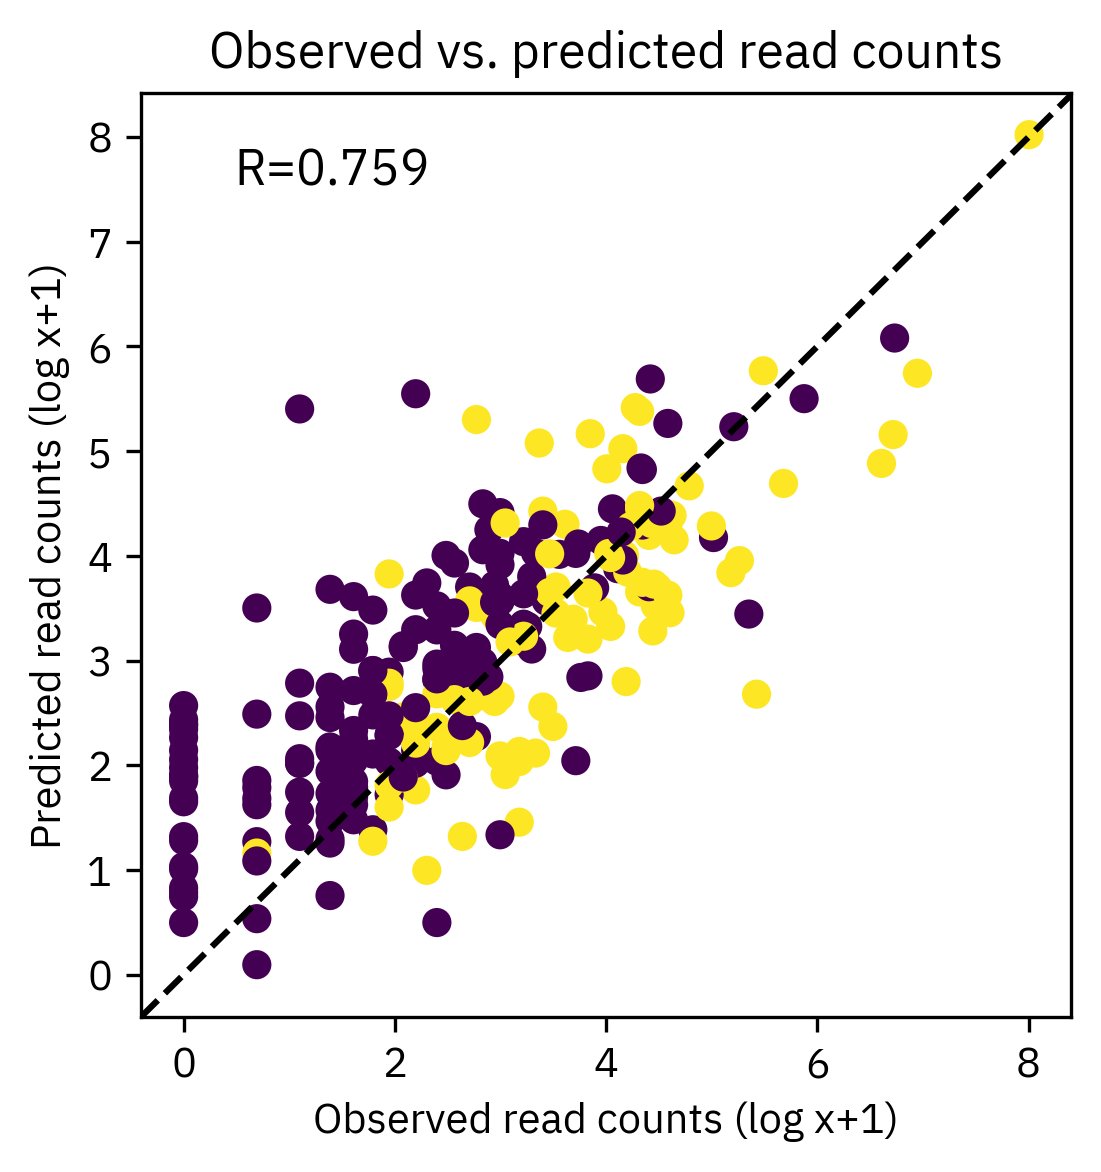

In [406]:
x = (target_counts + 1).log()
y = torch.logaddexp(log_pred_counts, torch.tensor(1).log())

plt.scatter(
    x,
    y,
    c=indicator,
)

plt.axline((0, 0), slope=1, color="k", ls="--")

plt.xlabel("Observed read counts (log x+1)")
plt.ylabel("Predicted read counts (log x+1)")

pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted read counts")

plt.gcf().set_size_inches(4, 4)

Text(0.5, 1.0, 'Observed vs. predicted density')

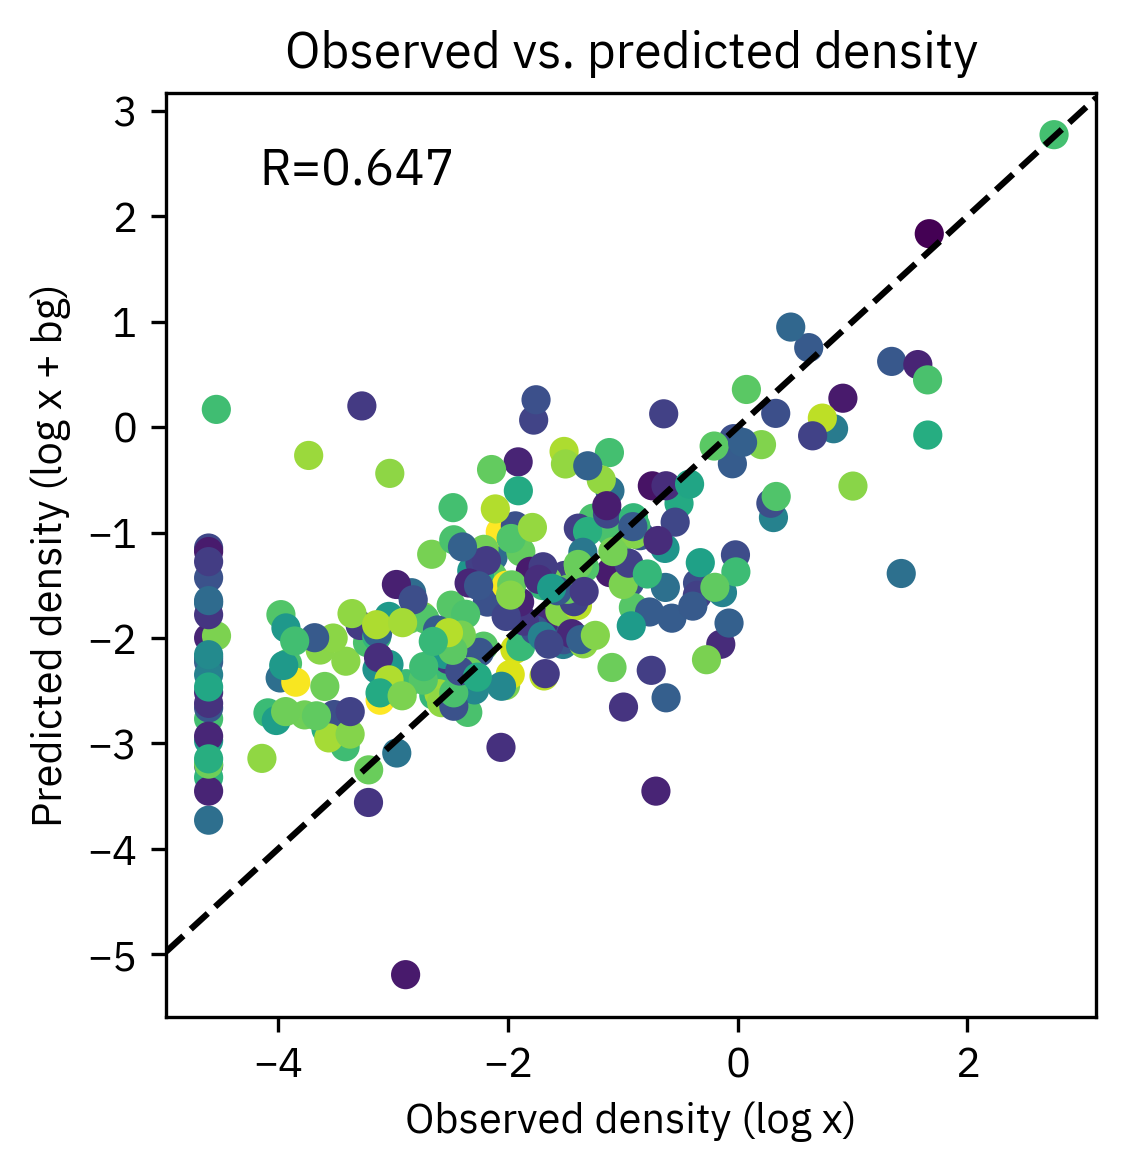

In [407]:
x = (density).log()
y = pred_total_density.log()

plt.scatter(x, y, c=torch.log(read_depth))
plt.gcf().set_size_inches(4, 4)

plt.axline((0, 0), slope=1, color="k", ls="--")

plt.xlabel("Observed density (log x)")
plt.ylabel("Predicted density (log x + bg)")


pearsonr = scipy.stats.pearsonr(x, y)

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

plt.title("Observed vs. predicted density")

In [408]:
# x = (density - ).log()
# y = pred_total_density.log()

# plt.scatter(x, y, c=torch.log(read_depth))
# plt.gcf().set_size_inches(4, 4)

# plt.axline((0, 0), slope=1, color="k", ls="--")

# plt.xlabel("Observed density (log x)")
# plt.ylabel("Predicted density (log x + bg)")


# pearsonr = scipy.stats.pearsonr(x, y)

# t = plt.text(
#     0.1,
#     0.9,
#     f"R={pearsonr.statistic:0.3f}",
#     fontdict=dict(fontsize="large"),
#     transform=plt.gca().transAxes,
# )

# plt.title("Observed vs. predicted density")

#### Predicted vs. observed peak densities

Text(0, 0.5, 'Peak density')

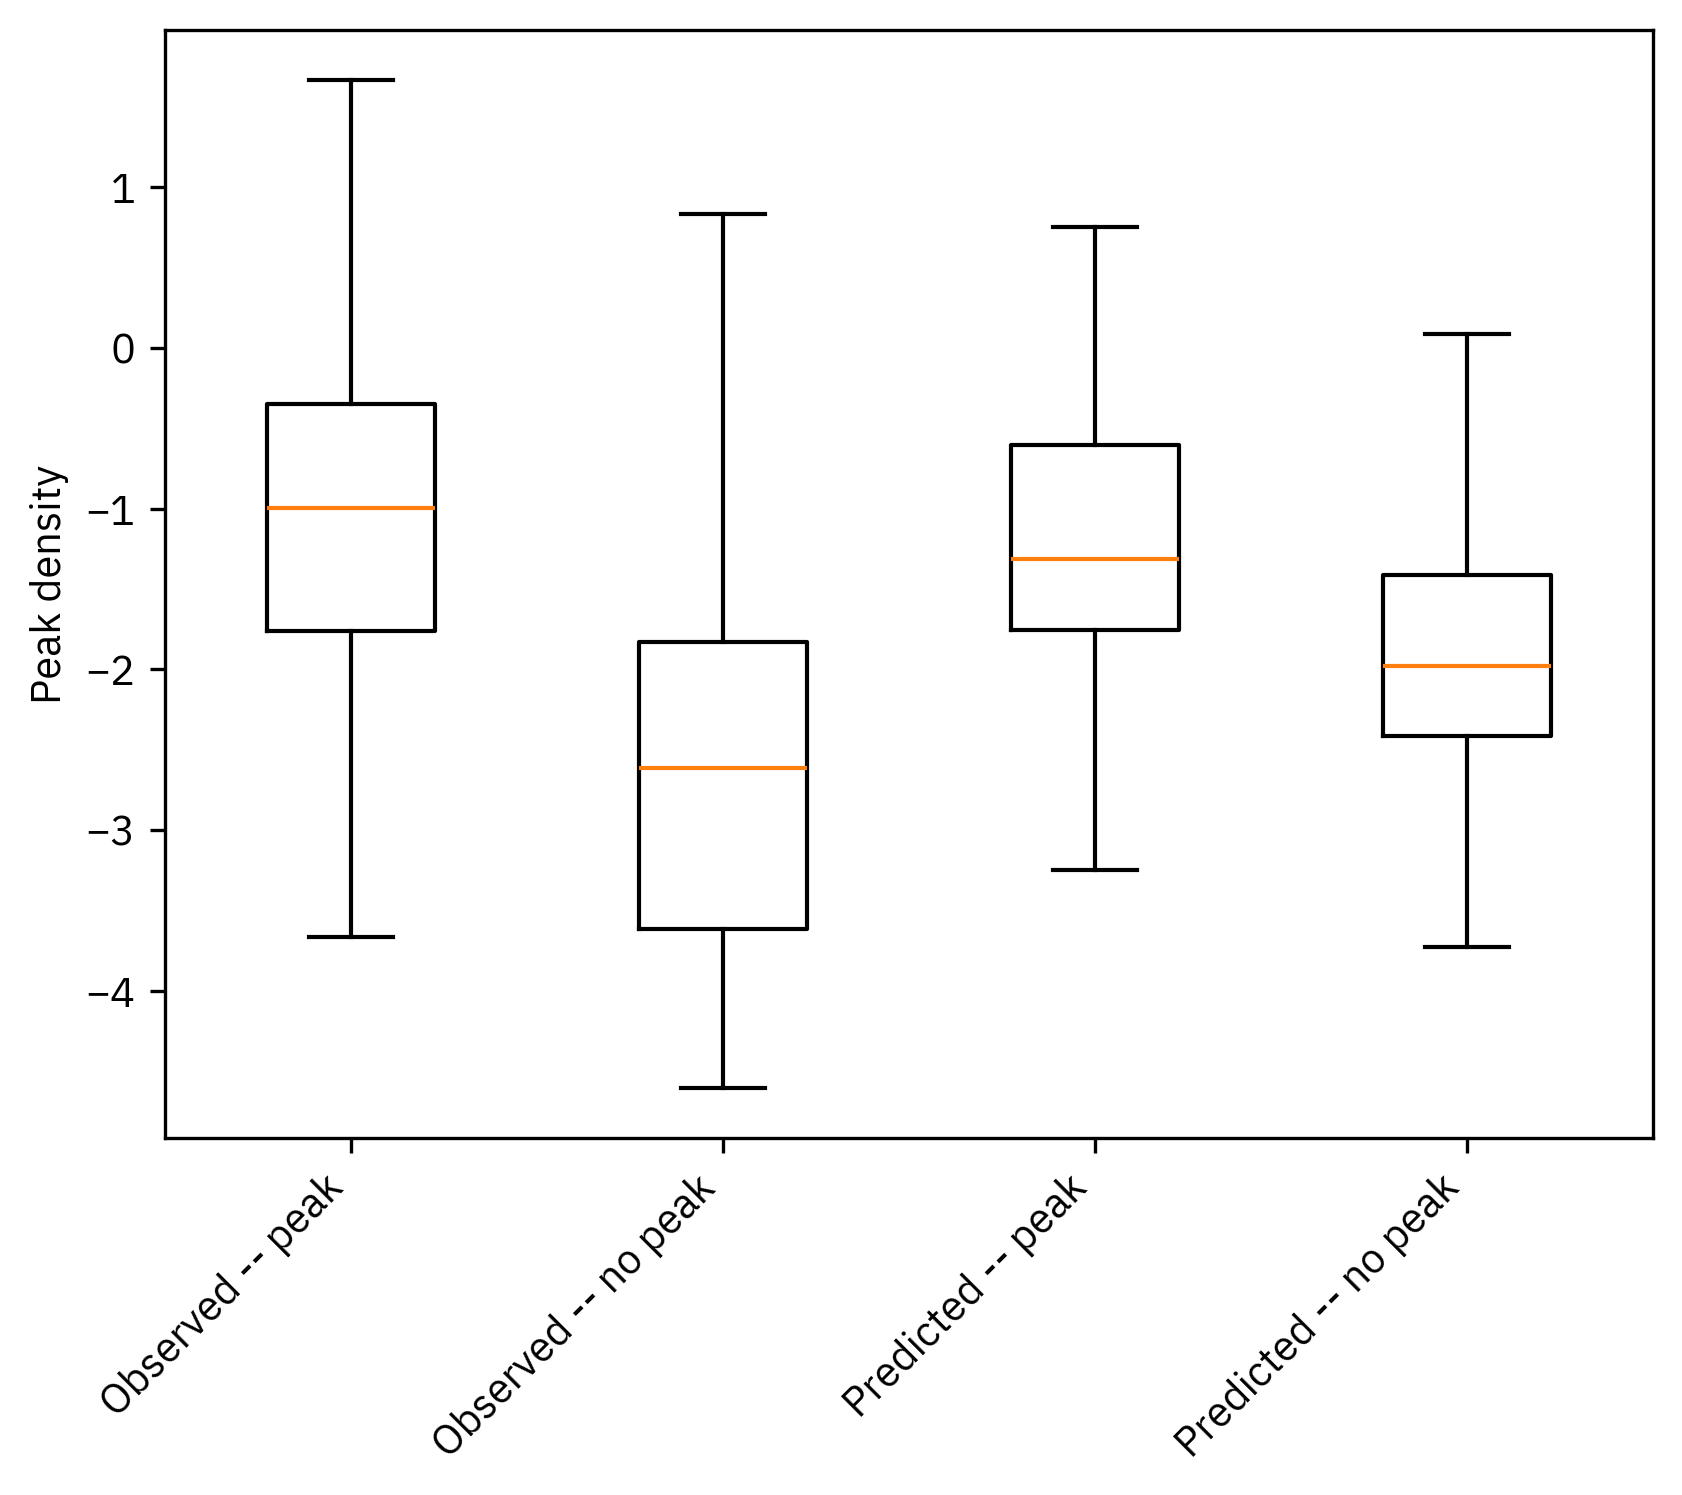

In [409]:
pred_w_peak = pred_total_density.log()[(indicator == 1).to(bool)]
pred_wo_peak = pred_total_density.log()[(indicator == -1).to(bool)]


obs_w_peak = (density).log()[(indicator == 1).to(bool)]
obs_wo_peak = (density).log()[(indicator == -1).to(bool)]

y = [
    obs_w_peak,
    obs_wo_peak,
    pred_w_peak,
    pred_wo_peak,
]

b = plt.boxplot(y, showfliers=False)

plt.xticks(
    np.arange(len(y)) + 1,
    labels=[
        "Observed -- peak",
        "Observed -- no peak",
        "Predicted -- peak",
        "Predicted -- no peak",
    ],
    rotation=45,
    ha="right",
)

plt.ylabel("Peak density")

#### Loss landscape

Text(0.5, 1.0, 'Loss landscape for batch')

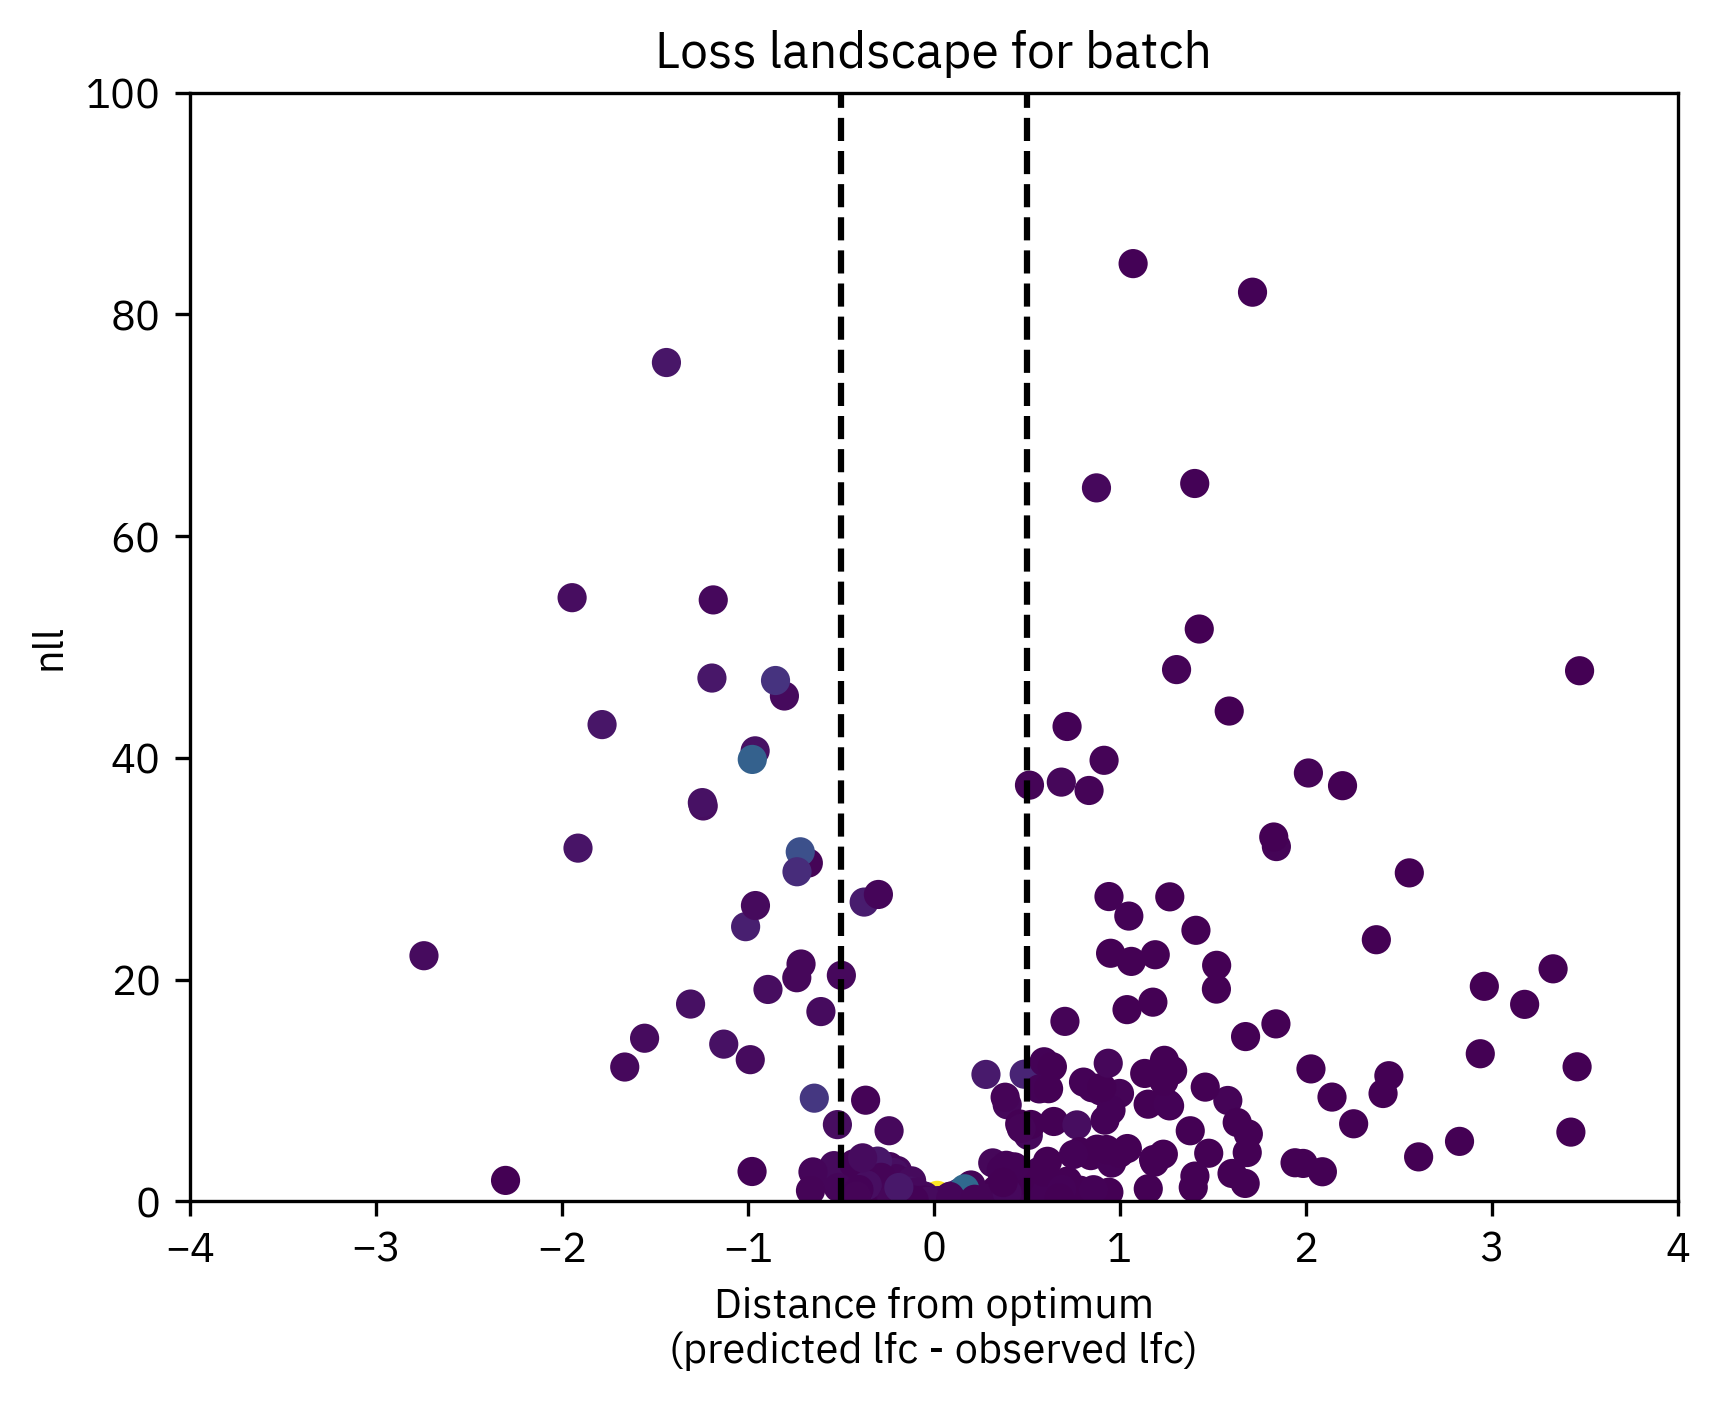

In [410]:
lfc = (torch.log(pred_total_density) - torch.log(density))

ax = plt.gca()

ax.scatter(lfc, loss, label="delta NLL", c=density)
ax.axvline(-0.5, color="k", ls="--")
ax.axvline(0.5, color="k", ls="--")

plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
ax.set_ylabel("nll")

ax.set_xlim(-4, 4)
ax.set_ylim(0, 100)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Loss landscape for batch")

#### Prediction error by peak density

Text(0.5, 1.0, 'Model prediction error by peak density')

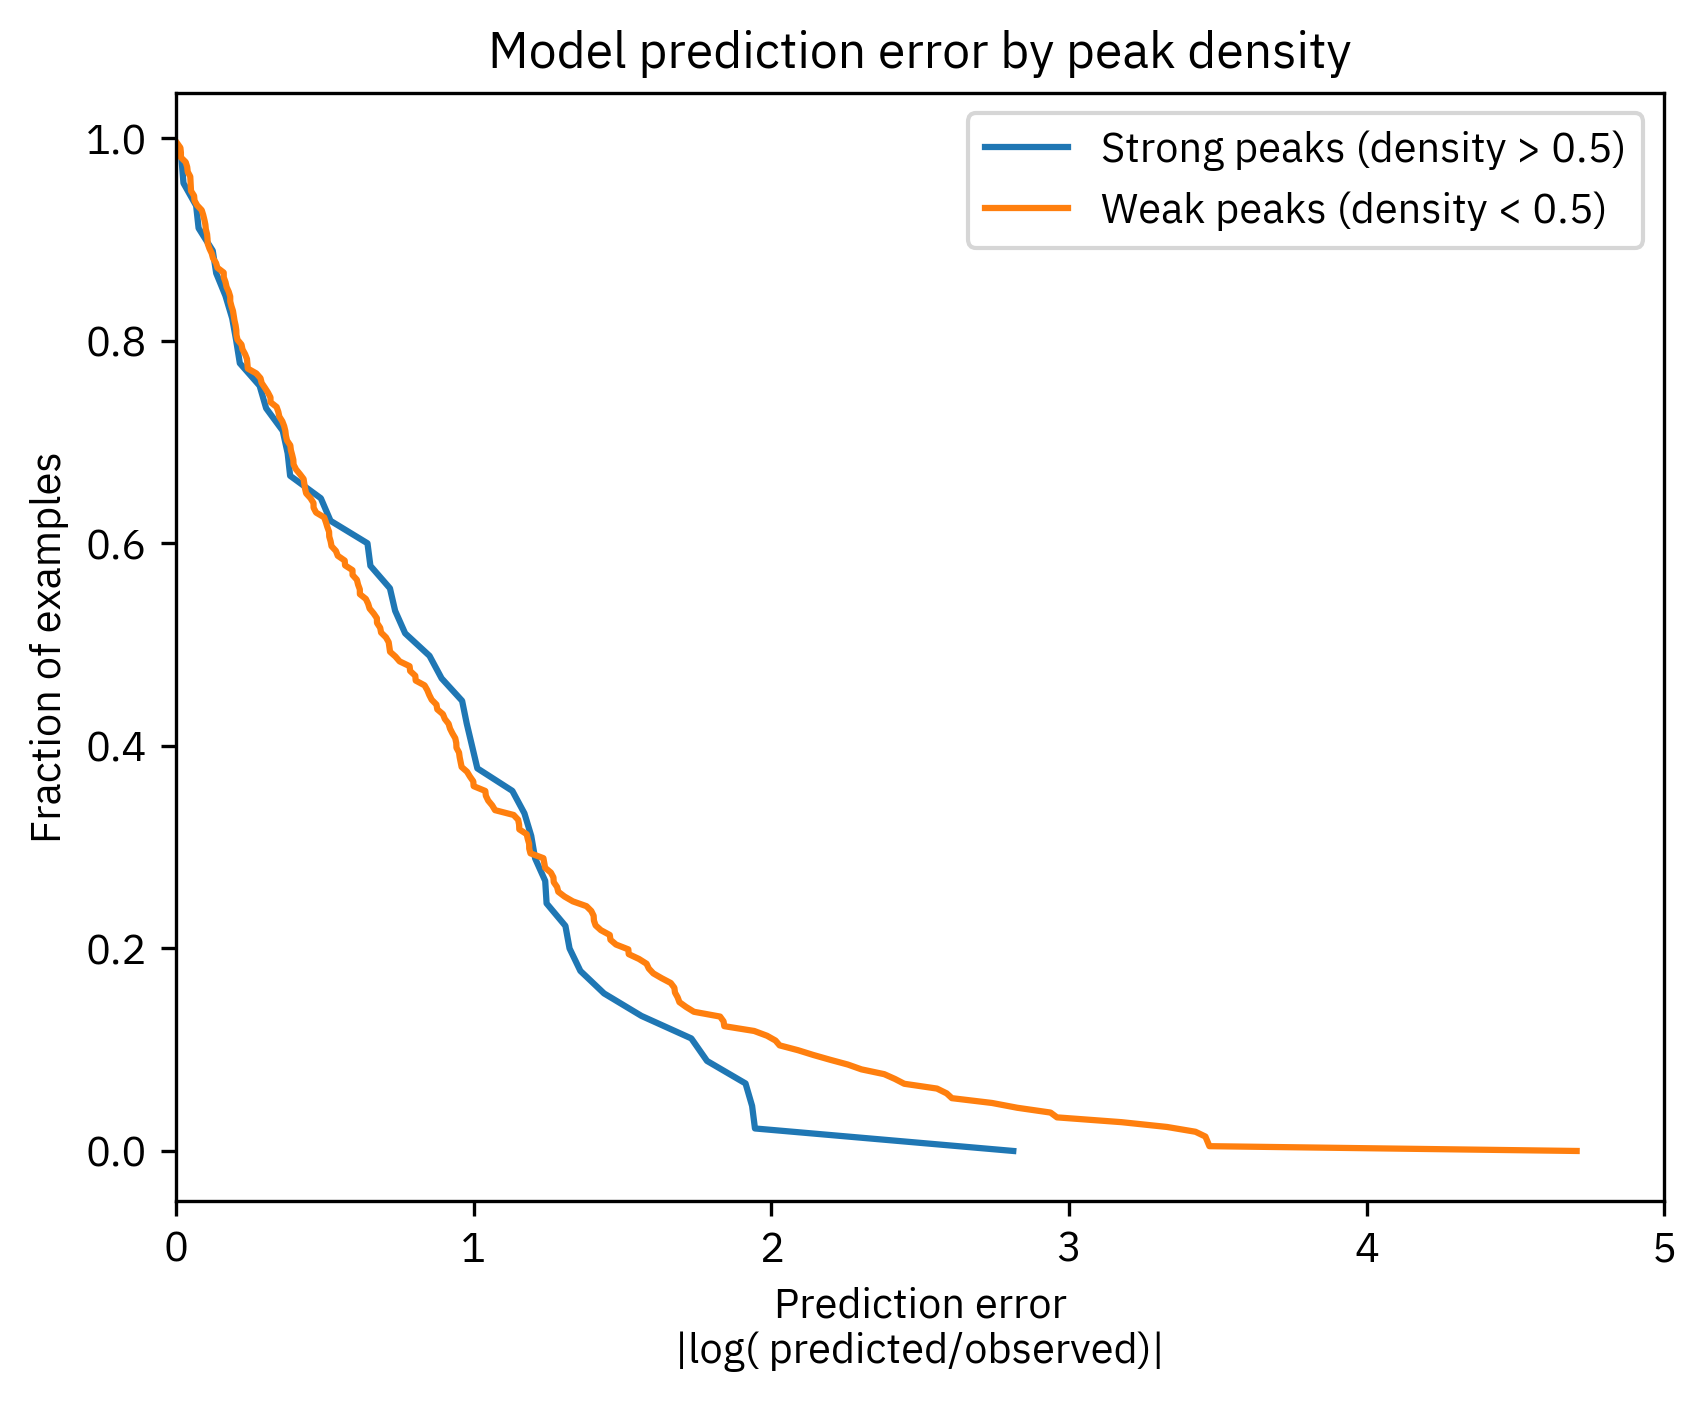

In [411]:
lfc_abs = lfc.abs()

x = lfc_abs[density > 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Strong peaks (density > 0.5)")

x = lfc_abs[density < 0.5]
rank = np.arange(len(x)) / len(x)
plt.plot(np.sort(x)[::-1], rank, label="Weak peaks (density < 0.5)")

plt.xlabel("Prediction error\n|log( predicted/observed)|")
plt.ylabel("Fraction of examples")

plt.legend()

plt.xlim(0, 5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

plt.title("Model prediction error by peak density")

(array([ 2.,  0.,  5.,  6., 14., 11., 15., 18.,  7.,  4.]),
 array([-2.81273127, -2.43769979, -2.06266809, -1.68763649, -1.3126049 ,
        -0.93757331, -0.56254172, -0.18751001,  0.18752146,  0.56255293,
         0.93758464]),
 <BarContainer object of 10 artists>)

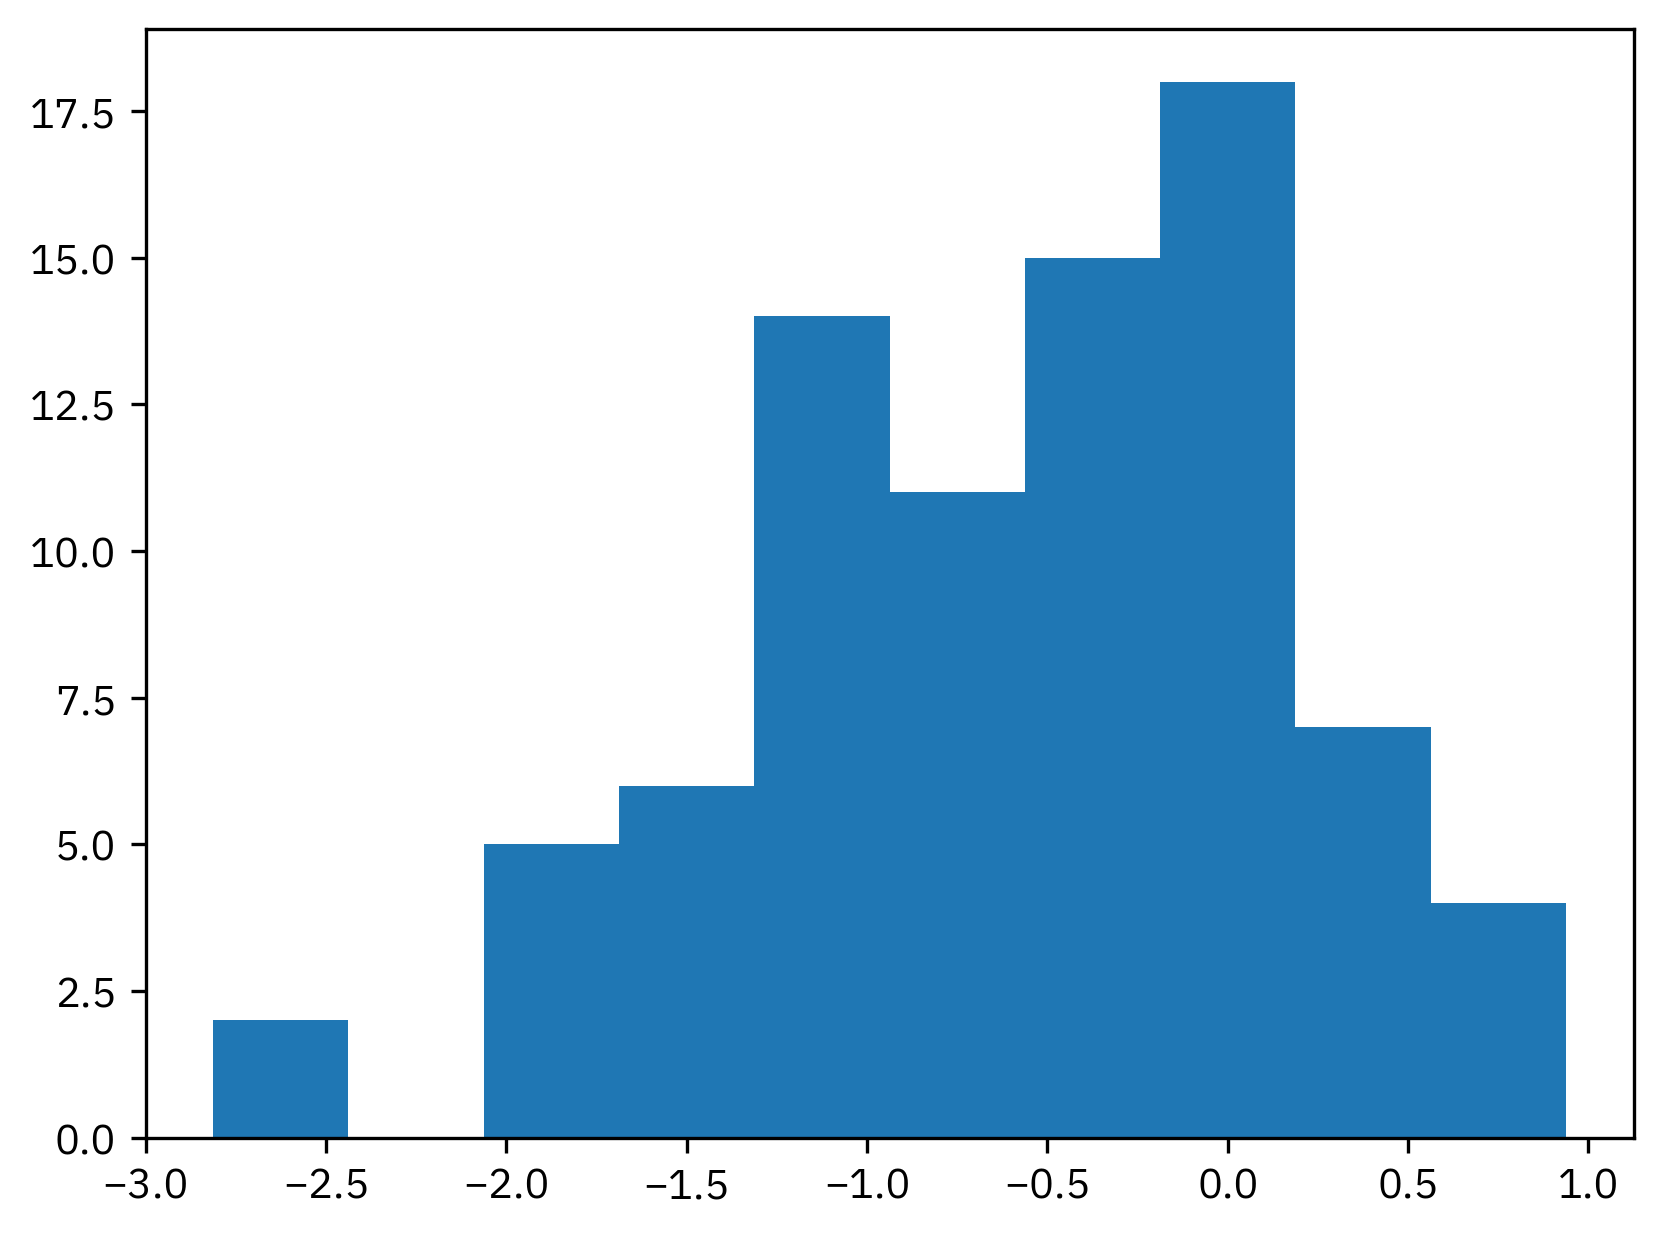

In [412]:
plt.hist(lfc[density>0.25])

### Contribution scores

In [413]:
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

from vinson.interpretation import dinucleotide_shuffle, force_strict_ohe
from vinson.models.helpers import _Exp

class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super(Wrapper, self).__init__()
        self.model = model
        self.exp = _Exp()
    def forward(self, seq, embed):
        x = self.model(seq, embed)
        if self.model.log_output:
            x = self.exp(x)
        return x

model_wrapper = Wrapper(model_predict)
model_wrapper = model_wrapper.eval()

In [414]:
weight[np.argsort(density)]

tensor([1.0560, 5.3626, 2.0601, 1.3541, 1.3263, 1.4655, 2.0607, 1.7288, 1.3262,
        1.4772, 1.9655, 1.3387, 3.6495, 1.2138, 1.0291, 1.7645, 1.9769, 2.3465,
        2.7860, 1.2839, 1.2306, 1.2024, 1.4631, 1.6563, 1.1154, 4.3428, 1.0582,
        1.2127, 1.3345, 1.7711, 1.0638, 1.6151, 1.1114, 1.7957, 1.3074, 1.3925,
        2.4226, 2.4733, 1.0049, 1.2410, 1.6267, 1.2959, 1.1677, 1.6927, 1.3733,
        1.5616, 1.1515, 2.4629, 1.7546, 2.0259, 5.5810, 1.0135, 1.7432, 1.3688,
        1.7263, 2.1004, 2.1354, 1.3165, 1.3334, 1.2360, 2.1436, 1.7499, 1.3289,
        2.0600, 1.6329, 1.4530, 2.2046, 2.0946, 2.6538, 2.5309, 2.2773, 1.0570,
        1.4351, 1.3730, 1.3478, 1.6234, 1.5700, 2.2348, 1.6236, 1.8510, 1.2141,
        1.2769, 1.3025, 4.0972, 3.5831, 4.9121, 1.4517, 1.5409, 1.2161, 1.3820,
        1.4252, 1.4894, 1.3549, 4.6847, 1.2777, 1.6669, 1.3853, 2.0120, 1.8082,
        1.7467, 2.2896, 4.7161, 3.1238, 1.1551, 1.1912, 1.7402, 3.0664, 1.2685,
        1.0483, 1.9987, 1.2861, 1.3225, 

In [415]:
w = np.where(weight < 10, weight, 0)
np.argmax(w)

np.int64(119)

In [416]:
np.argsort(density)

tensor([  0,   4,  17,  32,  49,  60,  93,  66, 102, 108, 126, 115,  82,  90,
        144, 149, 216, 237, 238, 185, 165, 228, 245, 249, 175, 225, 110, 214,
         43, 107,  27,  36, 169, 248,  74,  22, 193, 113, 194,  85, 171, 212,
         54, 202,   5, 173, 155, 170,  42,  13, 204, 255,  99,  51,  67,  31,
        145,  33, 222,  81,  80, 121, 156, 197,  78,  37, 154,  77, 178, 120,
        172, 235, 253, 231, 137,  44, 117, 135, 209,   8, 147, 188, 127,  19,
        247,  47,  30,  64, 232,  73,   3,  86, 136, 151,  69, 240,  83, 215,
        122,  35, 124, 206, 186, 210, 203, 220, 142,  84, 229, 205, 105,  94,
         10, 236, 234,  68, 112, 148,   6,  59, 150,  11,  25,  61,  14, 162,
         26,  12, 168,  45, 251, 133,  65, 254, 207, 217,  48,  79,   2, 158,
        182, 139,  52, 146, 132, 218, 174, 143, 199, 233, 153, 163, 195,  38,
         91, 243, 157, 230, 242, 201,  88,  23,  24,  34,   7,   9, 129, 187,
        152,  70, 161, 119, 219,  89,  92, 191, 200, 116, 223, 1

In [468]:
i = 135
y_[i], density[i], weight[i]

(tensor(0.1567), tensor(0.0585), tensor(2.2348))

In [469]:
# You to do this because dinucleotide shuffle cannot deal with ambiguous bases
_X = force_strict_ohe(X_seq[i : i + 1].clone())

Y_embed = X_embed[i : i + 1].clone()

# Run DeepLIFT/SHAP
attrs = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

Y_embed_rand = torch.tensor(dataset.embeddings_df.iloc[1, :].values[np.newaxis,:]).to(torch.float32)

attrs_rand = deep_lift_shap(
    model_wrapper,
    _X,
    args=(Y_embed_rand,),
    device="cpu",
    print_convergence_deltas=True,
    references=dinucleotide_shuffle,
    additional_nonlinear_ops={
        _Exp: _nonlinear
    }
)

tensor([1.8626e-09, 1.8626e-08, 0.0000e+00, 3.7253e-08, 0.0000e+00, 7.4506e-09,
        7.4506e-09, 1.4901e-08, 7.4506e-09, 1.9558e-08, 7.4506e-09, 7.4506e-09,
        1.1176e-08, 5.9605e-08, 7.4506e-09, 4.0978e-08, 2.2352e-08, 0.0000e+00,
        2.6077e-08, 1.4901e-08], grad_fn=<AbsBackward0>)
tensor([2.9802e-08, 1.7881e-07, 8.9407e-08, 5.9605e-08, 2.9802e-08, 2.6822e-07,
        8.9407e-08, 8.1956e-08, 1.0058e-07, 5.9605e-08, 5.9605e-08, 2.9802e-08,
        1.1921e-07, 2.9802e-08, 2.9802e-08, 2.9802e-08, 1.1921e-07, 8.9407e-08,
        1.6391e-07, 2.9802e-07], grad_fn=<AbsBackward0>)


572


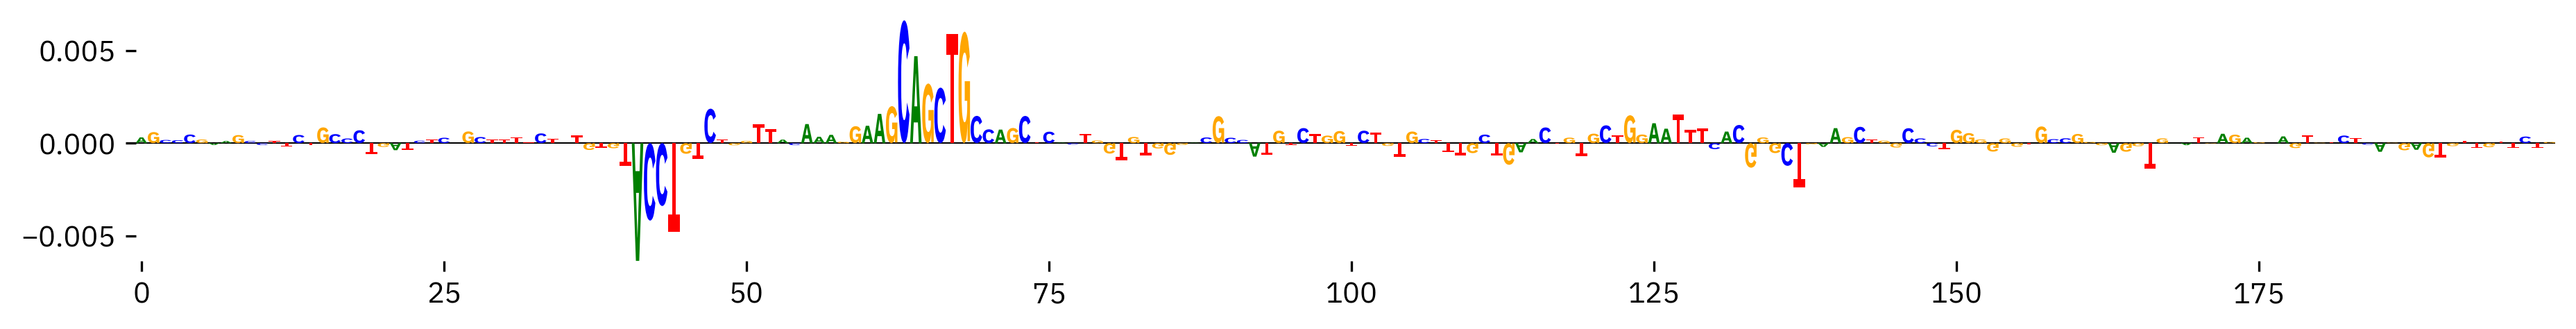

In [470]:
from tangermeme.plot import plot_logo

d = 100
d = _X.shape[-1] // 2 - d
print(d)

x = attrs[0][:, d:-d]
t = torch.max(x).numpy()
fig, ax = plt.subplots()
plot_logo(x, ax=ax)
ax.set_ylim(top=t)
fig.set_size_inches(15, 1.5)

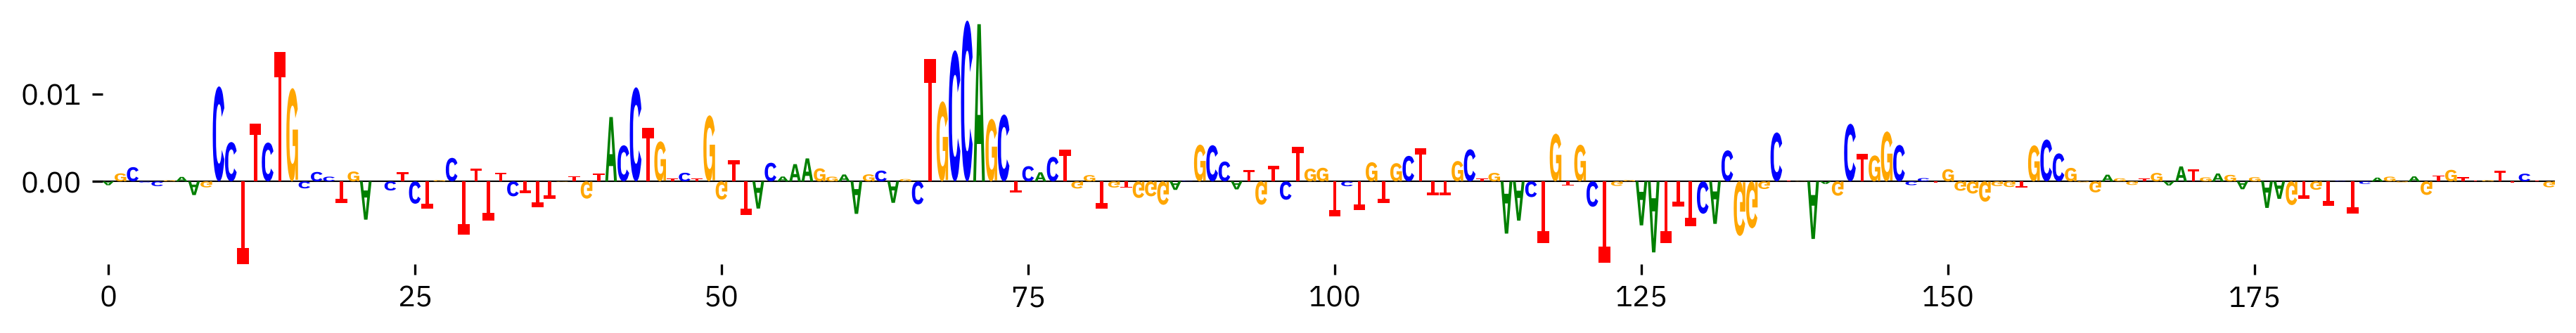

In [471]:
fig, ax = plt.subplots()
plot_logo(attrs_rand[0][:, d:-d], ax=ax)
# ax.set_ylim(top=t)
fig.set_size_inches(15, 1.5)

## Load and predict by dhs_id

In [540]:
# custom_model = model_predict
# embeddings_df = vinson_training_data.obsm['motif_embeddings']

In [571]:
custom_model = legnet_model
embeddings_df = pd.read_table('/home/jvierstra/proj/vinson/data/embeddings_clustername.tsv', index_col=0).loc[vinson_training_data.obs_names]

In [572]:
annotation_data = pd.read_table('/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/cell_selective//annotation_data.tsv')

In [573]:
from tangermeme.predict import predict
from tangermeme.product import apply_pairwise

In [639]:
def slice_adata(adata, dhs_ids, sample_ids):
    adata_slice = adata[:, :]
    if dhs_ids is not None:
        adata_slice = adata_slice[:, dhs_ids]
    if sample_ids is not None:
        adata_slice = adata_slice[sample_ids, :]
    return adata_slice


def get_evaluation_dataset(training_anndata, dhs_ids=None, sample_ids=None):
    adata_slice = slice_adata(training_anndata, dhs_ids, sample_ids)

    print('compute on density', flush=True)
    density_values = pd.DataFrame(
        adata_slice.layers["density"].compute(),
        index=adata_slice.obs_names,
        columns=adata_slice.var_names
    )

    print('compute on bg', flush=True)
    background_values = pd.DataFrame(
        adata_slice.layers["mean_bg_agg_cutcounts"].compute(),
        index=adata_slice.obs_names,
        columns=adata_slice.var_names
    )

    example_class_values = pd.DataFrame(
        adata_slice.layers["binary"].toarray(),
        index=adata_slice.obs_names,
        columns=adata_slice.var_names
    ).replace({False: -1, True: 1})

    values = pd.concat({
        'density': density_values,
        'background': background_values,
        'class': example_class_values,
    }, axis=1).stack(level=1).rename_axis(index=['sample_id', 'dhs_id']).reset_index()

    print('mapping other stuff', flush=True)
    values['read_depth'] = values['sample_id'].map(adata_slice.obs['nuclear_reads'].to_dict())
    values['indiv_id'] = values['sample_id'].map(adata_slice.obsm['indiv_id']['indiv_id'].to_dict())

    values['chrom'] = values['dhs_id'].map(adata_slice.var['#chr'].to_dict())
    values['summit'] = values['dhs_id'].map(adata_slice.var['dhs_summit'].to_dict())

    return values

In [575]:
weights = pd.read_table('/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/cell_selective/mean_fc_squared_weights_max50.tsv').set_index('dhs_id')['weight']

In [576]:
dhs_id = human_data.var.rename(columns={'#chr': 'chrom'}).query(f'dhs_summit == {mid[i]} & chrom == "{chrom[i]}"').index
dhs_id = dhs_id[0]
dhs_id

'chunk1654_2934_2'

In [615]:
dhs_id = 'chunk1350_5396_2' #BCL11A
dhs_id = 'chunk1671_3300_1'# Not related to cell type, very well correlated
dhs_id = 'chunk1645_2283_2'

In [616]:
weights[dhs_id]

np.float64(7.332624763382953)

In [640]:
data = get_evaluation_dataset(vinson_training_data, dhs_id).to_dict()

data.keys()

compute on density
compute on bg
mapping other stuff


/tmp/ipykernel_221910/316082710.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({False: -1, True: 1})
/tmp/ipykernel_221910/316082710.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  values = pd.concat({


dict_keys(['sample_id', 'dhs_id', 'density', 'background', 'class', 'read_depth', 'indiv_id', 'chrom', 'summit'])

In [641]:
custom_dataset = SequenceEmbedDataset(
    data=data,
    embeddings_df=embeddings_df,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
)


In [642]:
custom_dataloader = DataLoader(
    custom_dataset,
    batch_size=vinson_training_data.shape[0],
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [643]:
btch = next(iter(custom_dataloader))

/home/sabramov/miniconda3/envs/pytorch/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [636]:
%%time
Y_all = custom_model(btch["ohe_seq"], btch["embed"]).squeeze().detach()

CPU times: user 23.9 s, sys: 8.12 s, total: 32.1 s
Wall time: 8.11 s


In [623]:
dhs_index = np.where(data_module.adata.var_names == dhs_id)[0]
in_training = np.zeros(vinson_training_data.shape[0], dtype=bool)
for epoch_name in data_module.adata.uns['epoch_names'][:-1]:
    example_class = data_module.adata.layers[f'class.{epoch_name}'][:, dhs_index]
    in_training |= example_class.toarray()[:, 0] != 0
in_training.sum()

np.int64(316)

In [624]:
r = np.corrcoef(embeddings_df, btch['density'], rowvar=False)[-1, :-1]
embeddings_df.columns[np.argsort(r)][np.sort(r) >= 0.65]

Index([], dtype='object')

In [625]:
selected_motif_clustrer = embeddings_df.columns[np.argmax(r)]
selected_motif_clustrer, r[np.argmax(r)]

('SPI/BCL11A', np.float64(0.5061787661279706))

In [626]:
# selected_motif_clustrer = 'AC0246'

In [627]:
np.sort(r)[np.sort(r) >= 0.65]

array([], dtype=float64)

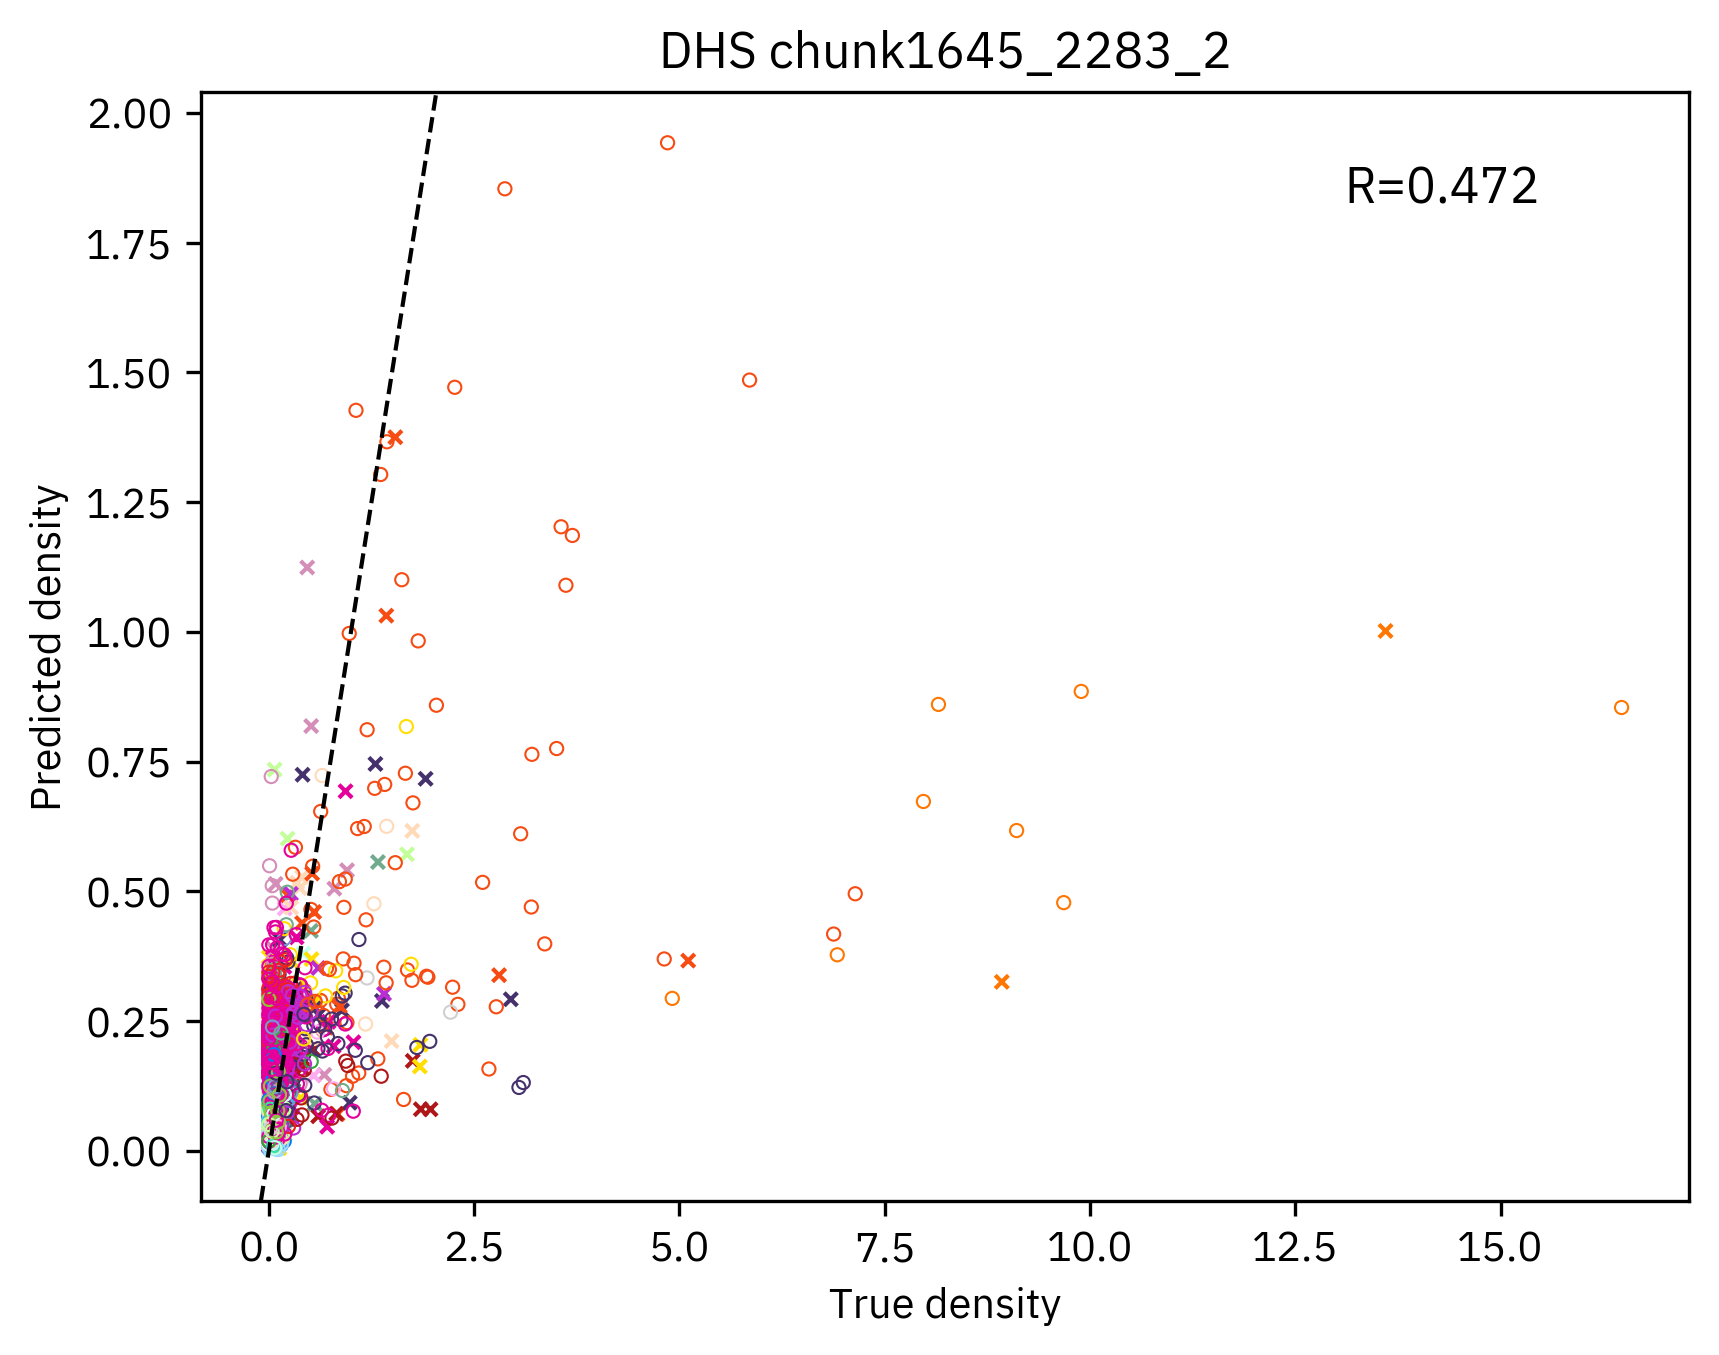

In [628]:
plt.scatter(
    btch['density'][in_training],
    Y_all[in_training],
    s=10,
    marker='x',
    lw=1,
    c=vinson_training_data.obs['extended_annotation'].map(annotation_data.set_index('extended_annotation')['color']).fillna('#D0D0D0').values[in_training],
    # c=vinson_training_data.obs['nuclear_reads'].values[in_training],
    # c=embeddings_df.loc[:, selected_motif_clustrer].values[in_training],
)

plt.scatter(
    btch['density'][~in_training],
    Y_all[~in_training],
    s=10,
    marker='o',
    lw=0.5,
    edgecolors=vinson_training_data.obs['extended_annotation'].map(annotation_data.set_index('extended_annotation')['color']).fillna('#D0D0D0').values[~in_training],
    # c=vinson_training_data.obs['nuclear_reads'].values[~in_training],
    # c=embeddings_df.loc[:, selected_motif_clustrer].values[~in_training],
    c='none',
)

pearsonr = scipy.stats.pearsonr(btch['density'], Y_all)

t = plt.text(
    0.9,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
    ha='right',
)
# plt.ylim(0, max(max( np.clip(true_densities_all, 0, 20)), max(Y_all.squeeze())))

plt.axline((0, 0), slope=1, color='k', lw=1, ls='--')

plt.xlabel('True density')
plt.ylabel('Predicted density')
plt.title(f'DHS {dhs_id}')
# plt.axhline(5)
plt.show()




In [629]:
results_obs = vinson_training_data.obs.copy()
results_obs['density'] = btch['density']
results_obs['predicted'] = Y_all

In [630]:
results_by_ann = results_obs.groupby('extended_annotation')[['density', 'predicted']].mean().loc[annotation_data['extended_annotation']]

/tmp/ipykernel_221910/1704515565.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_by_ann = results_obs.groupby('extended_annotation')[['density', 'predicted']].mean().loc[annotation_data['extended_annotation']]


In [631]:
anncols = annotation_data.set_index('extended_annotation').loc[results_by_ann.index]['color'].values

/tmp/ipykernel_221910/3150233397.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


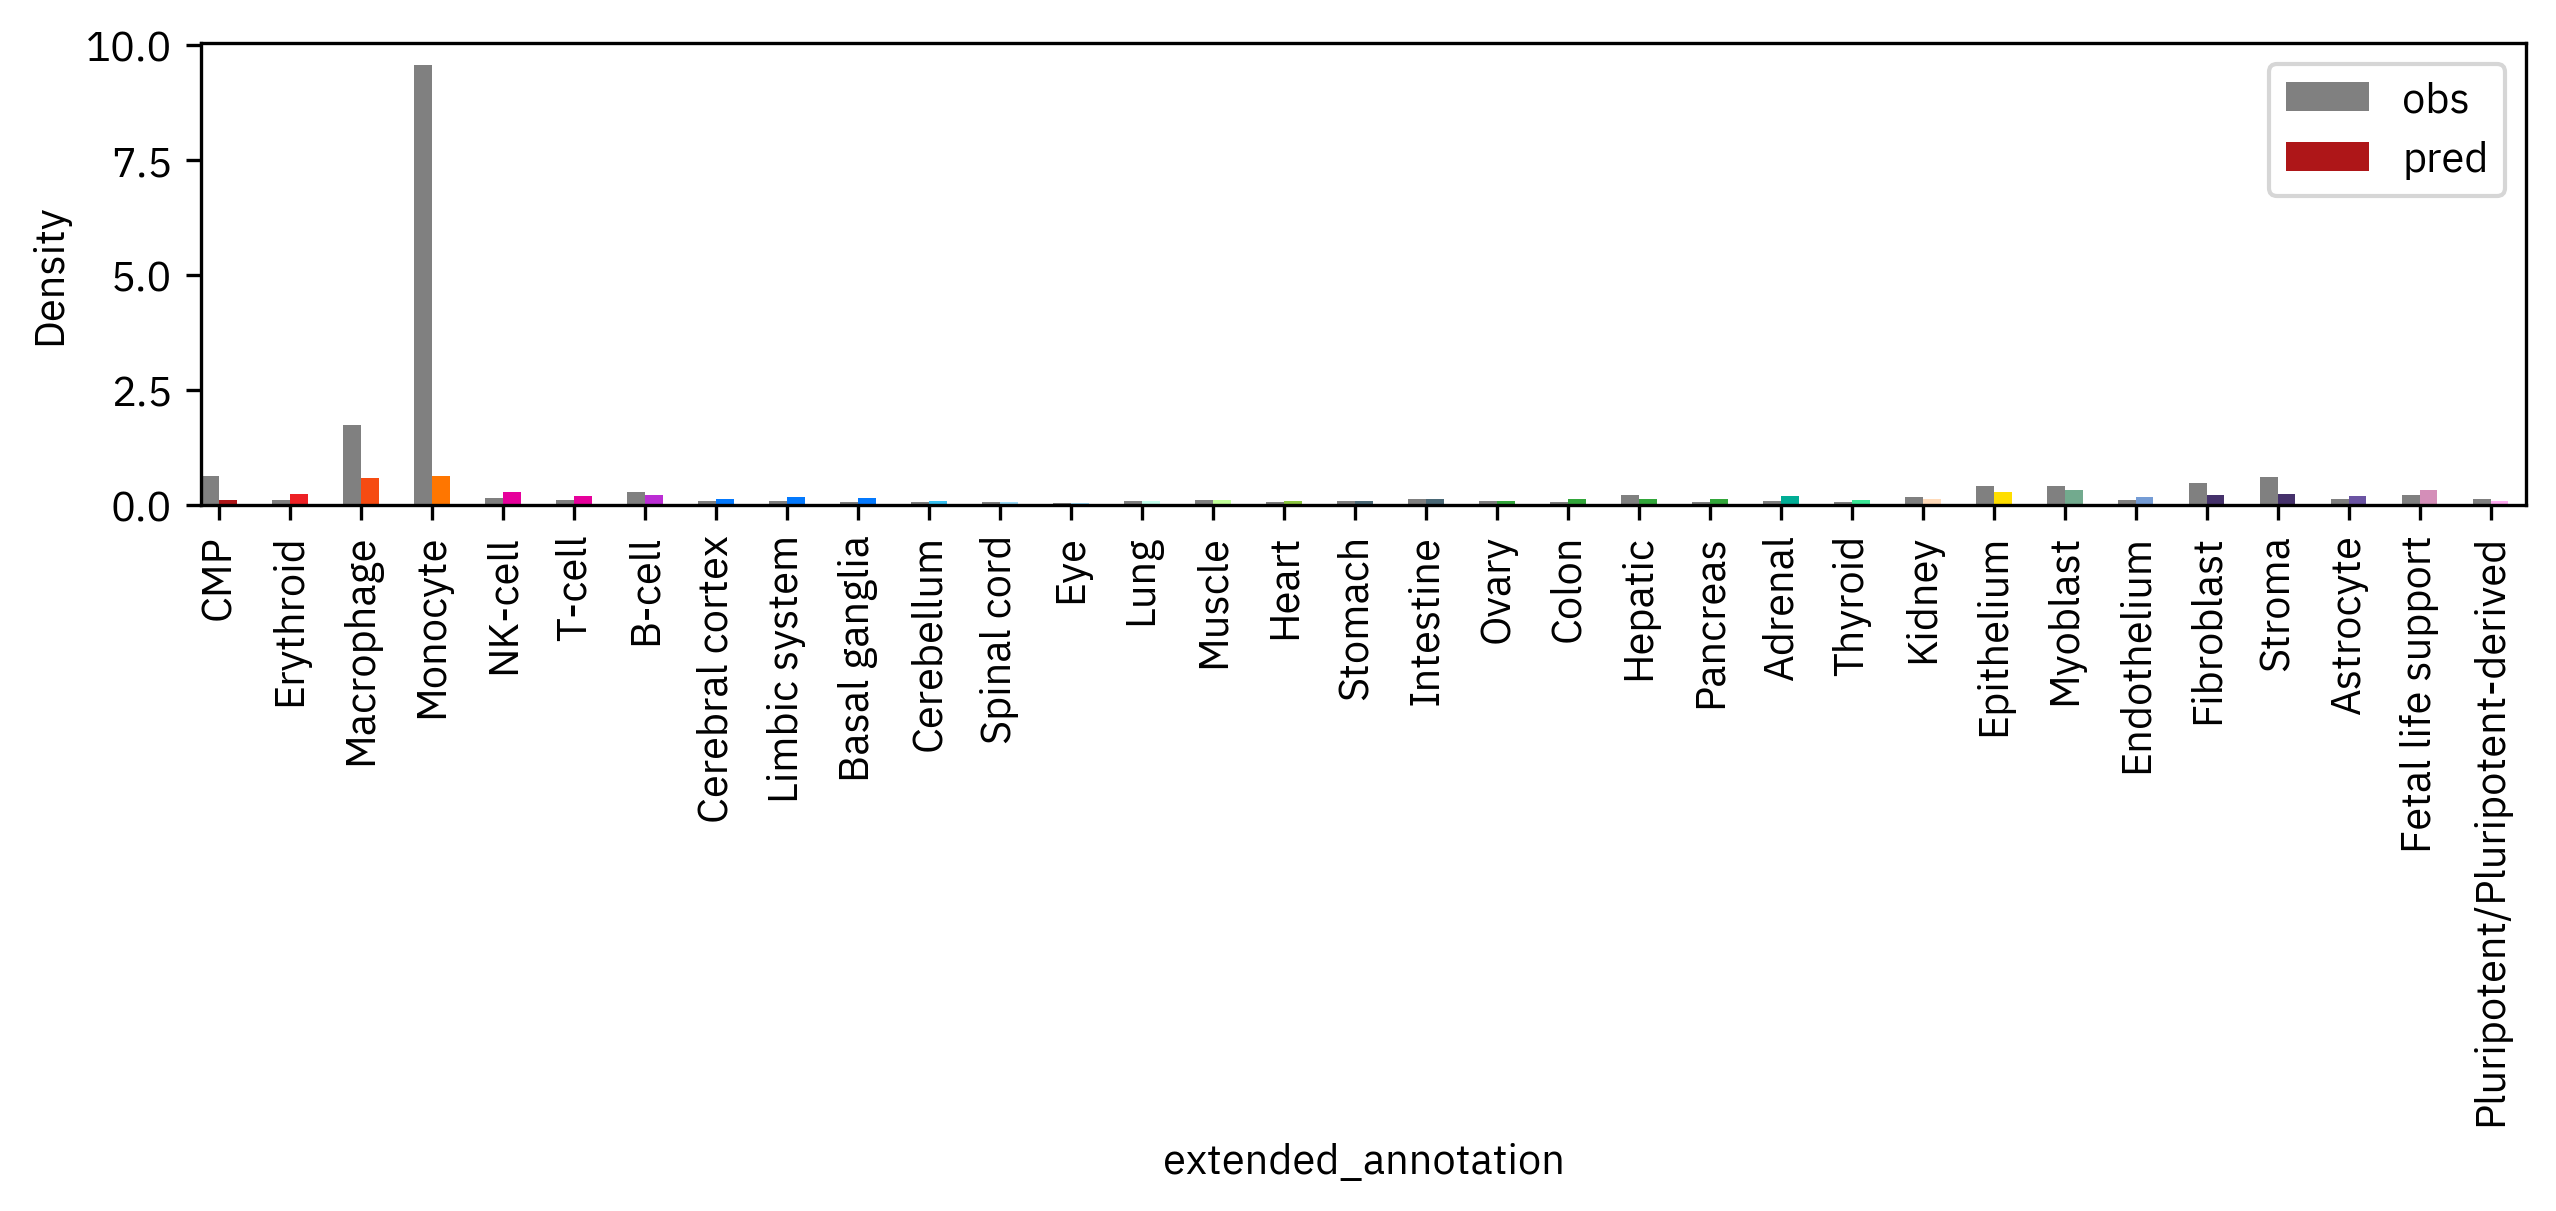

In [635]:
fig, ax = plt.subplots(figsize=(10, 2))

# plot 'obs' first (solid grey)
results_by_ann['density'].plot(kind='bar', ax=ax, color='grey', width=0.25, position=1, label='obs')

# plot 'pred' second, with individual colors
results_by_ann['predicted'].plot(kind='bar', ax=ax, color=anncols, width=0.25, position=0, label='pred')

ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

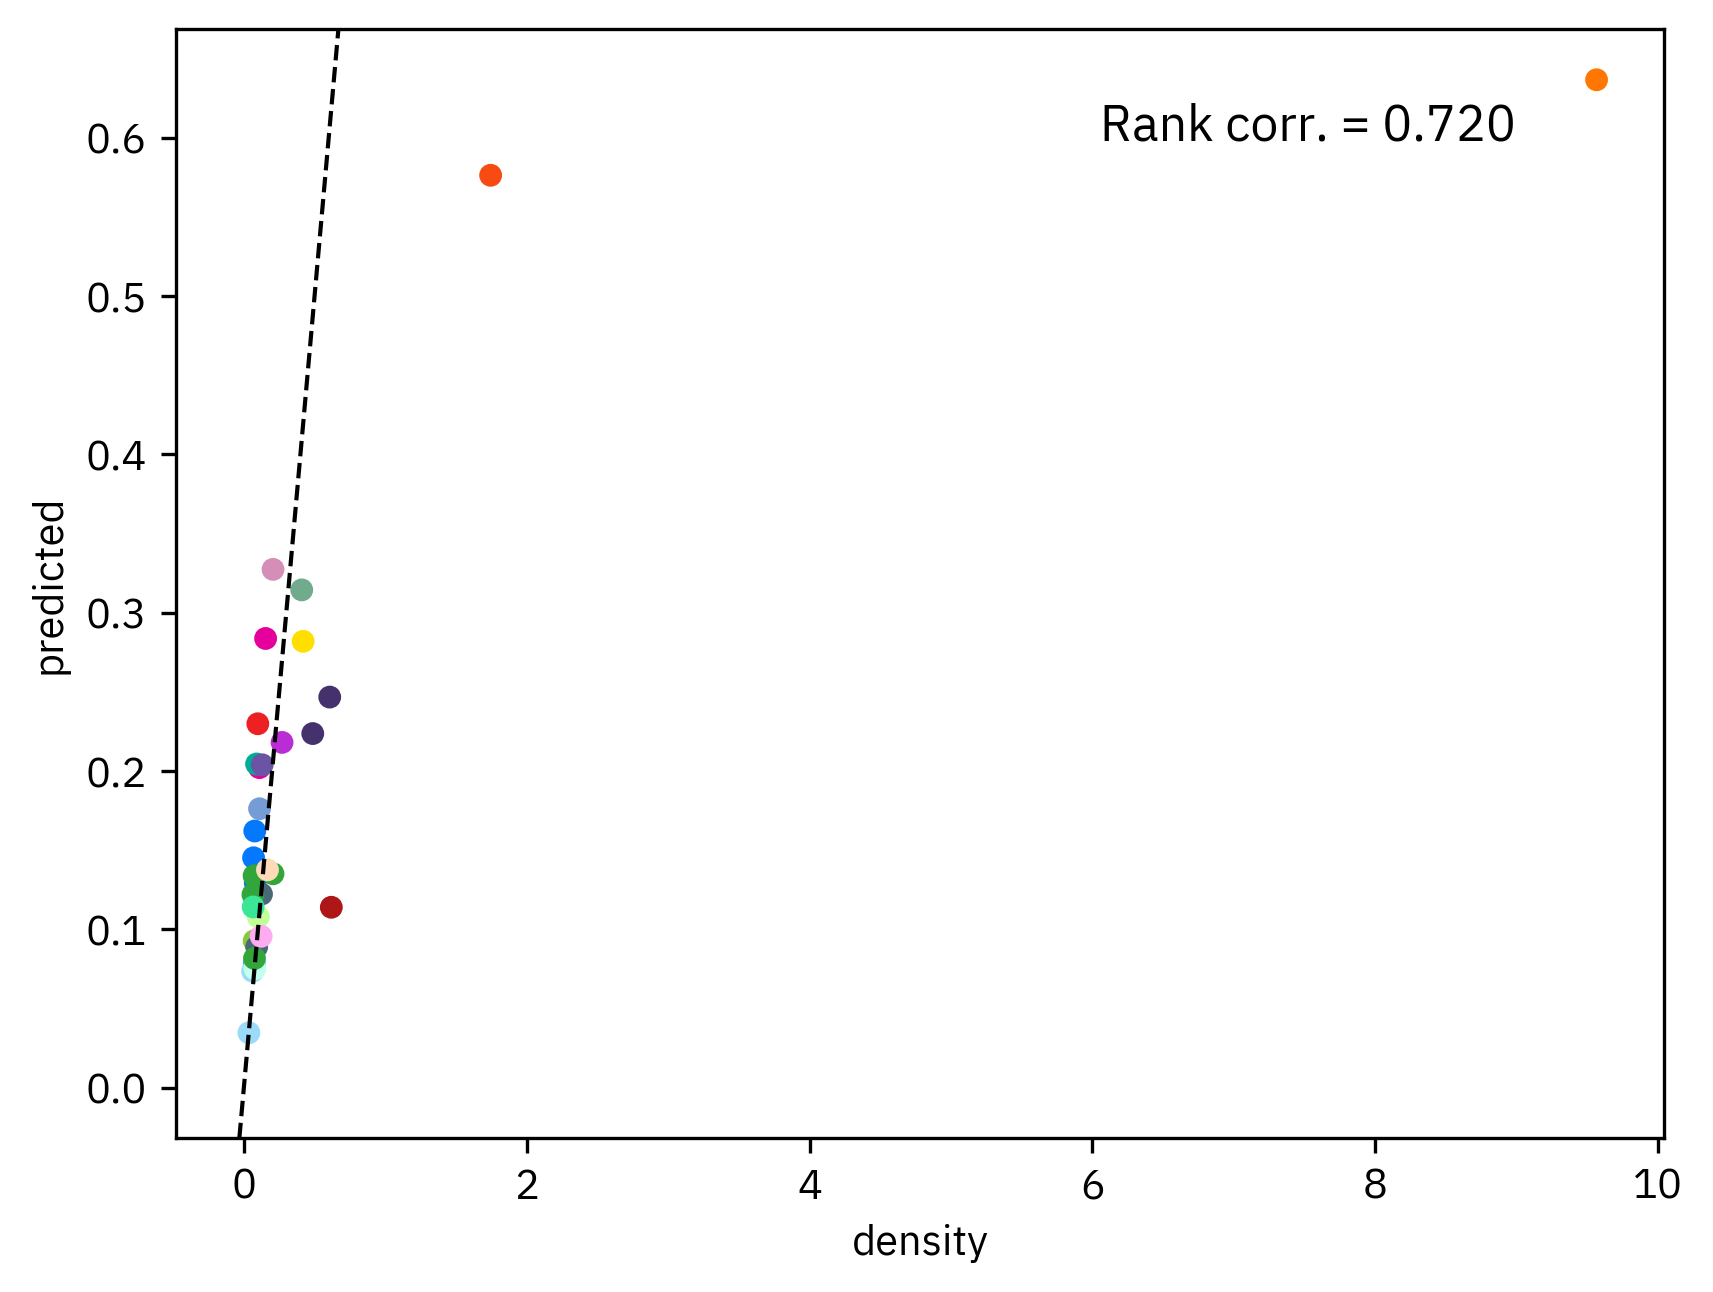

In [633]:
results_by_ann.plot(x='density', y='predicted', kind='scatter', c=anncols)
plt.axline((0, 0), slope=1, color='k', lw=1, ls='--')

spearmanr = scipy.stats.pearsonr(results_by_ann['density'], results_by_ann['predicted'])

t = plt.text(
    0.9,
    0.9,
    f"Rank corr. = {spearmanr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
    ha='right',
)

### One sample

In [647]:
def get_dhs_ids_for_sample_peaks(adata, sample_id):
    peaks_mask = adata[sample_id, :].layers['binary'].toarray().squeeze()
    return adata.var_names[peaks_mask]

In [649]:
# sample_id = vinson_training_data.obs_names[0]

In [675]:
data_module.adata.obs[data_module.adata.obsm['split_data'] == 'val']

,ln_number,ds_number,tc_number,core_annotation,extended_annotation,core_ontology_term,sample_type,system,subsystem,organ,...,cutcounts_tabix,SPOT1_score,SPOT3_score,total_fastq_reads,nuclear_reads,alignment_quality,nuclear_dup_rate,peaks_file_0.001fdr,n_peaks,label
ag_id,,,,,,,,,,,,,,,,,,,,,
AG10697,LN28840,DS32574,TC114930,Pluripotent/Pluripotent-derived,Pluripotent/Pluripotent-derived,Cardiac myocyte,Stem/progenitor,Cardiovascular,Cardiac muscle,Heart,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.3408,0.250649,102018778,67932386,0.665881,0.064881,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,201425,Pluripotent/Pluripotent-derived
AG58688,LN65770,DS82968,TC11835,Brain,Basal ganglia,Caudate anterior,Primary cells/tissues,Nervous,Central,Brain,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.4994,0.330979,309833345,240247698,0.775409,0.306186,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,156347,Basal ganglia
AG58698,LN65752,DS82950,TC11811,Brain,Basal ganglia,Caudate anterior,Primary cells/tissues,Nervous,Central,Brain,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.4374,0.204492,203399340,156985246,0.771808,0.191644,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,85639,Basal ganglia
AG58707,LN65736,DS82934,TC11793,Brain,Basal ganglia,Caudate anterior,Primary cells/tissues,Nervous,Central,Brain,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.4936,0.290107,210774076,142445066,0.675819,0.300441,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,142644,Basal ganglia
AG58771,LN64632,DS81995,TC11573,Brain,Cerebral cortex,Cortex,Primary cells/tissues,Nervous,Central,Brain,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.4639,0.234768,137089170,108974918,0.794920,0.255355,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,126885,Cerebral cortex
AG62159,LN26314,DS26001,TC4701,Myeloid,Macrophage,M2 macrophage,Primary cells/tissues,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.6335,0.418299,27100002,12334138,0.455134,0.034490,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,120812,Macrophage
AG62249,LN59662,DS76529,TC2729,Brain,Cerebellum,Cerebellar hemisphere,Primary cells/tissues,Nervous,Central,Brain,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.8072,0.681685,57409144,47393558,0.825540,0.142306,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,159202,Cerebellum
AG62420,LN53995,DS70116,TC2886,Brain,Cerebellum,Cerebellar hemisphere,Primary cells/tissues,Nervous,Central,Brain,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.7988,0.659950,64111438,52736612,0.822577,0.119419,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,209408,Cerebellum
AG70920,LN27125,DS28393,TC4792,Myeloid,Macrophage,M2 macrophage,Primary cells/tissues,Hematopoietic,Myeloid,Blood,...,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,0.5047,0.377846,88018314,45326856,0.514971,0.069277,/net/seq/data2/projects/ENCODE4Plus/REGULOME/p...,282562,Macrophage


In [676]:
sample_id = 'AG4012'

In [677]:
sample_peaks_ids = get_dhs_ids_for_sample_peaks(vinson_training_data, sample_id)
sample_dataset_df = get_evaluation_dataset(vinson_training_data, dhs_ids=sample_peaks_ids, sample_ids=sample_id)

compute on density
compute on bg


/tmp/ipykernel_221910/316082710.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({False: -1, True: 1})


mapping other stuff


/tmp/ipykernel_221910/316082710.py:33: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  values = pd.concat({


In [678]:
sample_dataset = SequenceEmbedDataset(
    data=sample_dataset_df.to_dict(),
    embeddings_df=embeddings_df,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
)

sample_dataloader = DataLoader(
    sample_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    drop_last=False,
)

/home/sabramov/miniconda3/envs/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [679]:
@torch.inference_mode()
def load_and_predict(batch, model):    
    X_seq      = batch["ohe_seq"].to(device, non_blocking=True)
    X_embed    = batch["embed"].to(device, non_blocking=True)
    y_ = model(X_seq, X_embed).squeeze().detach()
    return y_

In [680]:
Y_sample = []
for b in tqdm(sample_dataloader):
    y_ = load_and_predict(b, custom_model).cpu()
    Y_sample.append(y_)
Y_sample = torch.cat(Y_sample).numpy()

  0%|                                                                    | 0/585 [00:00<?, ?it/s]/home/sabramov/miniconda3/envs/pytorch/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
100%|██████████████████████████████████████████████████████████| 585/585 [30:36<00:00,  3.14s/it]


In [681]:
Y_sample

array([0.22863239, 0.1877002 , 0.91220766, ..., 0.1311376 , 0.18633834,
       0.0866273 ], dtype=float32)

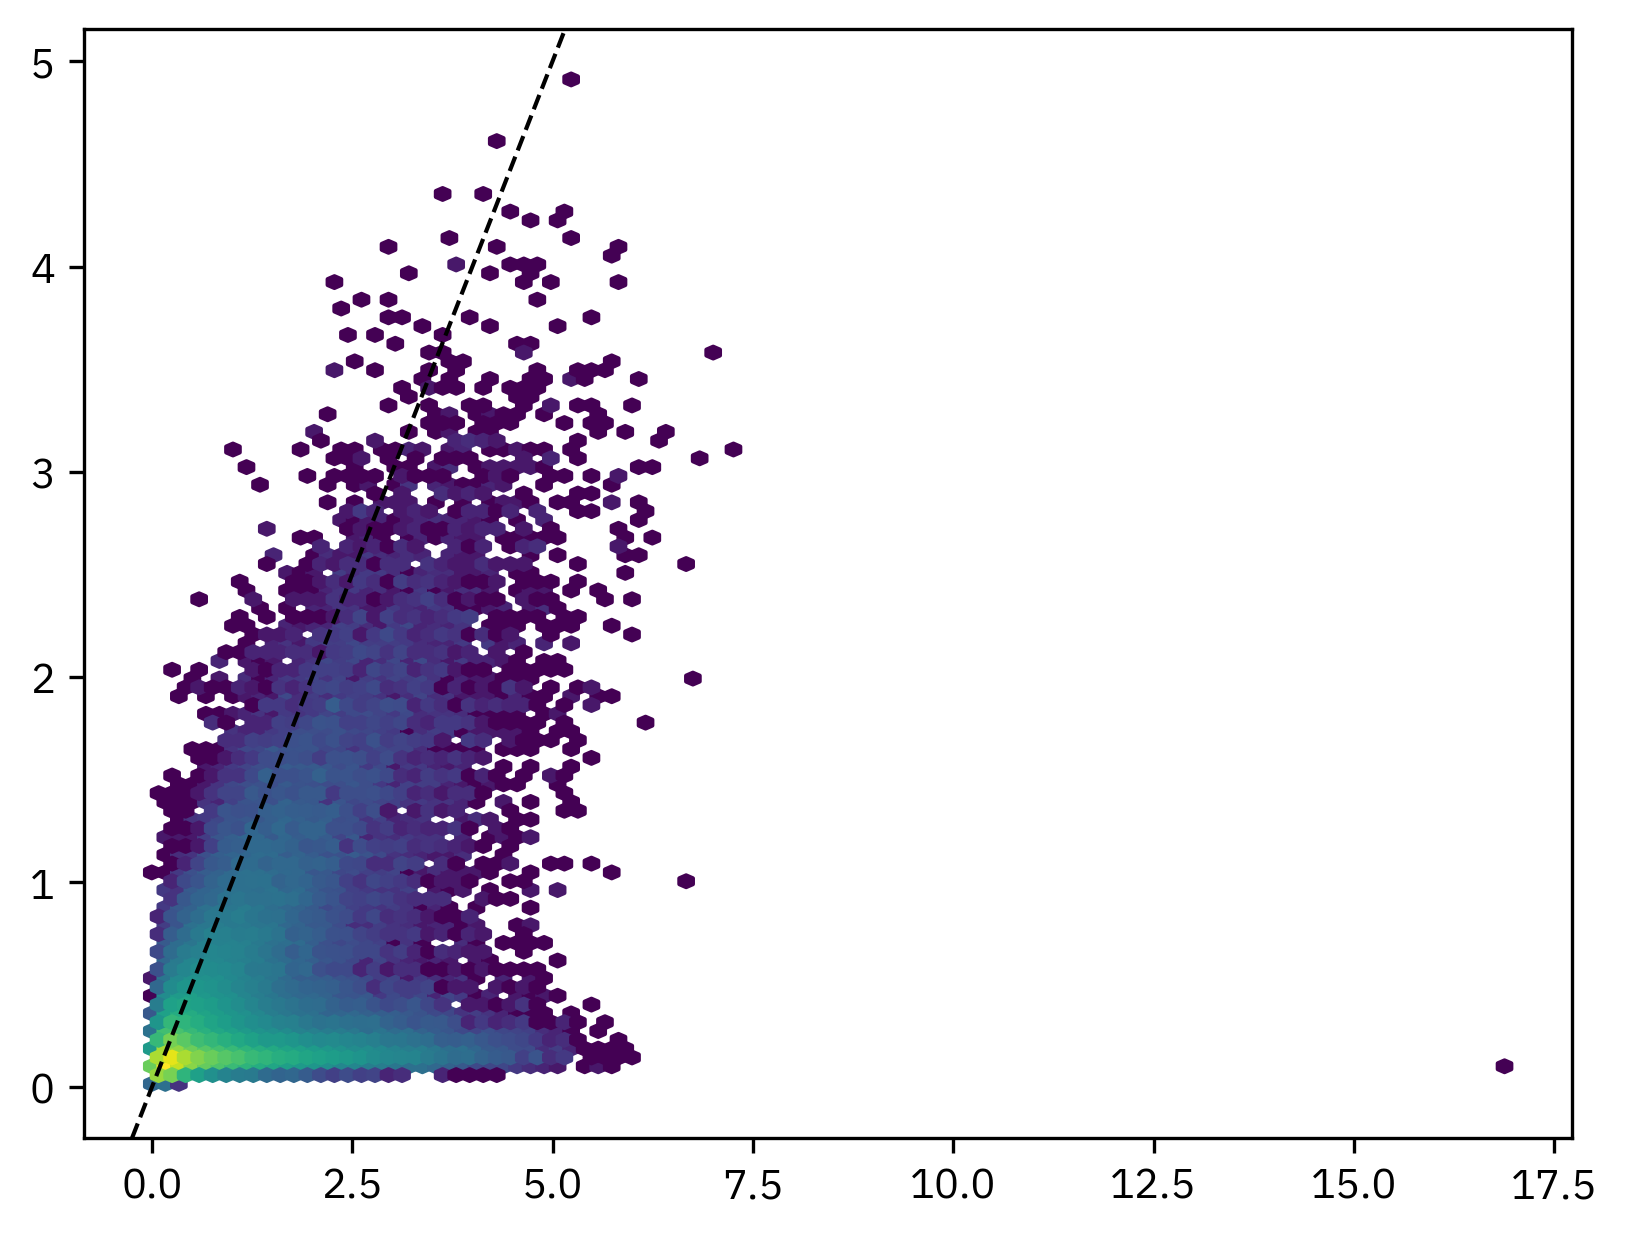

In [682]:
plt.hexbin(
    sample_dataset_df['density'],
    Y_sample,
    bins='log',
)
plt.axline((0,0), slope=1, color='k', lw=1, ls='--')

In [683]:
scipy.stats.pearsonr(sample_dataset_df['density'], Y_sample,)

PearsonRResult(statistic=np.float32(0.5198798), pvalue=np.float64(0.0))